# Play-style Distribution & Clustering of the 5 AI Archetypes - log_v2 - V1-V4 raw metrics only (`raw_*`)

**Data.** The full **`log_v2`** matrix: 5 search/AI play-styles (**aggro - control - fatigue - midrange - ramp**) x **9 decks** x ~900 games = 40,492 games. Each game is P1 (the folder's style) versus a varying opponent; we measure **P1 only** and **pool over all opponents and all 9 decks**. Features come precomputed from [`v2_features.py`](../v2_features.py) in [`out/features.csv`](../out/features.csv); labels (style/deck) are kept out of the feature matrix.

**This notebook's feature block.** This notebook uses the **V1-V4 raw block only** -- the 20 absolute, whole-game metrics (`raw_*`) that the earlier reports were built on (face damage/turn, avg/max card cost, attacks/turn, board size, mana spent/floated, ...). It is the **deck-leaky baseline**: these metrics conflate *what the deck does* with *what the player chose*, so they are expected to be strong **within** a deck and to transfer **poorly across** decks.

> **Models & metric (uniform everywhere).** Every **unsupervised** step is **KMeans**, every **supervised** step is **Linear Discriminant Analysis (LDA)**, and everything is scored with the **adjusted Rand index (ARI)** - so clustering and classification are read on one common scale where the **0.20 chance line** (5 equiprobable styles) is drawn for reference and a perfect answer = 1.000. PCA / t-SNE / LDA projections are used only for plotting. Per-style breakdowns are reported as **recall** (ARI has no per-class decomposition), and confusion matrices are kept as *where-the-errors-go* displays.

> **Layout.** Sections 1-10 mirror the Log_Analysis **V4** notebook (same sequence: per-game projection & clustering, supervised check, bootstrap fingerprints, held-out N-sweep, cross-deck transfer). Two changes from V4: models are restricted to KMeans + LDA and scored by ARI (V4 also used GMM and RandomForest and reported accuracy), and cross-deck (SS 9-10) uses the **full 9-deck matrix** with leave-one-deck-out (LODO) and leave-one-archetype-out (LOAO) instead of a single Mage<->Warrior pair. The three sibling notebooks (`raw` / `choice` / `both`) are **identical except for the `BLOCK` set in SS 1**, so their outputs are directly comparable.

## 1 - Setup & load

Load the precomputed per-game feature table and select this notebook's feature block. `FEATURES` = the columns fed to every model; `GRID_METRICS` = the columns shown in the distribution grids (for the choice block this also shows the 3 dropped diagnostics). Everything downstream reads `FEATURES`, so switching `BLOCK` re-runs the whole analysis on a different metric set.

In [1]:
import os, sys, itertools, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
warnings.filterwarnings("ignore")

# >>> the ONLY line that differs between the three notebooks <<<
BLOCK = "raw"   # "raw" | "choice" | "both"

def _repo_root():
    """Nearest ancestor holding both log_v2/ and log_v2_analysis/."""
    d = os.path.abspath(os.getcwd())
    while True:
        if os.path.isdir(os.path.join(d, "log_v2")) and os.path.isdir(os.path.join(d, "log_v2_analysis")):
            return d
        p = os.path.dirname(d)
        if p == d:
            raise FileNotFoundError("repo root (with log_v2/ + log_v2_analysis/) not found from " + os.getcwd())
        d = p
ROOT = _repo_root()
FEATURES_CSV = os.path.join(ROOT, "log_v2_analysis", "out", "features.csv")

%matplotlib inline
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.width", 200)

STYLE_ORDER  = ["aggro", "control", "fatigue", "midrange", "ramp"]
STYLE_COLORS = dict(zip(STYLE_ORDER, ["#d62728", "#1f77b4", "#9467bd", "#2ca02c", "#ff7f0e"]))
PALETTE      = [STYLE_COLORS[s] for s in STYLE_ORDER]

df = pd.read_csv(FEATURES_CSV)
df = df.dropna(subset=["style", "deck"]).copy()
df["style"] = pd.Categorical(df["style"], categories=STYLE_ORDER, ordered=True)

RAW    = [c for c in df.columns if c.startswith("raw_")]
CH_ALL = [c for c in df.columns if c.startswith("ch_")]
# diagnostics: option-supply / undefined-on-weaponless-decks -> shown in grids, excluded from models
CH_DROP = ["ch_n_options", "ch_face_dilemma_rate", "ch_hero_attack_face_pref"]
CH      = [c for c in CH_ALL if c not in CH_DROP]

if BLOCK == "raw":
    FEATURES, GRID_METRICS, BLOCK_LABEL = list(RAW), list(RAW), "V1-V4 raw metrics"
elif BLOCK == "choice":
    FEATURES, GRID_METRICS, BLOCK_LABEL = list(CH), list(CH_ALL), "choice-relative metrics"
elif BLOCK == "both":
    FEATURES, GRID_METRICS, BLOCK_LABEL = list(RAW) + list(CH), list(RAW) + list(CH_ALL), "raw + choice-relative metrics"
else:
    raise ValueError(BLOCK)

DECKS    = sorted(df["deck"].unique())
FAMILIES = sorted(df["deck_family"].dropna().unique())

def styles_of(frame):
    """Style labels as a plain numpy object array.

    `frame["style"].astype(str).values` can hand back a pandas extension (arrow-backed)
    array, which sklearn cannot index inside joblib workers -- so every label vector in
    this notebook goes through here.
    """
    return np.asarray(frame["style"].astype(str), dtype=object)

def kind_of(col):
    """Plot style for a metric's distribution."""
    if col in ("raw_n_turns", "raw_n_decisions", "raw_first_minion_turn", "raw_deck_count_end"):
        return "disc"
    if col in ("raw_face_attack_ratio", "raw_minion_frac"):
        return "clip01"
    if col.startswith("ch_") and col != "ch_n_options":
        return "clip01"
    return "kde"

print(f"BLOCK = {BLOCK!r}  ({BLOCK_LABEL})")
print(f"models: unsupervised = KMeans   supervised = LDA   metric = ARI (chance = 0.20)")
print(f"features.csv: {df.shape}  |  {len(FEATURES)} model features  |  {len(GRID_METRICS)} shown in grids")
print(f"decks ({len(DECKS)}): {DECKS}")
print(f"families ({len(FAMILIES)}): {FAMILIES}")
print("\ngames per style:")
print(df["style"].value_counts().reindex(STYLE_ORDER).to_string())
print(f"\noverall P1 win rate: {df['won'].mean():.1%}")
df[["game_file", "style", "deck", "deck_family", "won"]].head(3)

BLOCK = 'raw'  (V1-V4 raw metrics)
models: unsupervised = KMeans   supervised = LDA   metric = ARI (chance = 0.20)
features.csv: (40492, 45)  |  20 model features  |  20 shown in grids
decks (9): ['AggroPirateWarrior', 'MidrangeBuffPaladin', 'MidrangeJadeShaman', 'MidrangeSecretHunter', 'MiraclePirateRogue', 'MurlocDruid', 'RenoKazakusDragonPriest', 'RenoKazakusMage', 'ZooDiscardWarlock']
families (4): ['aggro', 'combo_tempo', 'highlander_control', 'midrange']

games per style:
style
aggro       8100
control     8099
fatigue     8100
midrange    8097
ramp        8096

overall P1 win rate: 50.0%


,game_file,style,deck,deck_family,won
0,game_001_aggro-AggroPirateWarrior_vs_aggro-Agg...,aggro,AggroPirateWarrior,aggro,0
1,game_001_aggro-AggroPirateWarrior_vs_aggro-Mid...,aggro,AggroPirateWarrior,aggro,0
2,game_001_aggro-AggroPirateWarrior_vs_aggro-Mid...,aggro,AggroPirateWarrior,aggro,1


### 1b - Metric glossary

All metrics are for **P1 (the folder's play-style)**, one value per game.

The **raw / V1-V4 block** (`raw_*`): 20 absolute, whole-game metrics for **P1** (one value per game). These are what the earlier V1-V4 reports used. They measure *what the deck handed the player* as much as what the player did, which is why they score high **within** a deck but leak deck identity **across** decks (quantified in SS 9-10).

| metric (column) | play-style aspect | definition |
|---|---|---|
| `raw_n_turns` | game length | number of P1 turns played |
| `raw_n_decisions` | activity | number of P1 decision points |
| `raw_face_dmg_per_turn` | life pressure / aggro | damage dealt to the enemy hero, per P1 turn |
| `raw_dmg_taken_per_turn` | damage absorbed | damage taken on P1's hero, per turn |
| `raw_heal_per_turn` | sustain | self-healing on P1's hero, per turn |
| `raw_face_attack_ratio` | aggression direction | face attacks / all P1 attacks |
| `raw_attacks_per_turn` | aggression intensity | total P1 attacks / turns |
| `raw_cards_per_turn` | tempo | cards P1 played / turns |
| `raw_avg_card_cost` | curve centre | mean mana cost of cards P1 played |
| `raw_max_card_cost` | reach / ramp | highest mana cost card P1 played |
| `raw_minion_frac` | card-type mix | minions / all cards played |
| `raw_mana_spent` | volume | total mana P1 spent this game |
| `raw_mana_spent_per_turn` | tempo | mana spent / turns |
| `raw_mana_floated_per_turn` | greed / inefficiency | unspent mana left at end of turn, per turn |
| `raw_hero_power_per_turn` | hero-power tempo | hero-power uses / turns |
| `raw_board_size_mean` | board presence | mean count of P1 minions in play at decisions |
| `raw_opp_minions_killed_per_turn` | removal / trading | enemy minions sent to graveyard, per turn |
| `raw_my_minions_lost_per_turn` | attrition | own minions lost, per turn |
| `raw_first_minion_turn` | midrange tell | turn the first P1 minion is played |
| `raw_deck_count_end` | fatigue tell | cards left in P1's deck at game end |

## 2 - Per-style distribution grids

One distribution grid **per style**, pooled over all 9 decks (the analogue of the reference's `show_player()`). Dashed line = that style's mean. Eyeball how the shapes shift from **aggro** toward the value styles.

In [2]:
def _plot_metric(ax, s, kind, color):
    s = s.dropna()
    if not len(s):
        return
    if kind == "disc":
        sns.histplot(s.round().astype(int), discrete=True, color=color, ax=ax, stat="density")
    elif kind == "clip01":
        sns.histplot(s.clip(0, 1), kde=(s.nunique() > 1), color=color, ax=ax, stat="density")
    else:
        sns.histplot(s, kde=(s.nunique() > 1), color=color, ax=ax, stat="density")
    ax.axvline(s.mean(), color="k", ls="--", lw=1)

def _grid_shape(n, ncol=4):
    return int(np.ceil(n / ncol)), ncol

def show_style(style):
    gp = df[df["style"] == style]
    display(Markdown(f"### `{style}`  -  {len(gp)} games  -  win {gp['won'].mean():.1%}  -  "
                     f"avg {gp['raw_n_turns'].mean():.1f} turns"))
    nrow, ncol = _grid_shape(len(GRID_METRICS))
    fig, axes = plt.subplots(nrow, ncol, figsize=(16, 2.9 * nrow)); axes = np.atleast_1d(axes).ravel()
    for ax, col in zip(axes, GRID_METRICS):
        _plot_metric(ax, gp[col], kind_of(col), STYLE_COLORS[style])
        ax.set_title(col, fontsize=8); ax.set_xlabel(""); ax.set_ylabel("")
    for ax in axes[len(GRID_METRICS):]:
        ax.axis("off")
    fig.suptitle(f"{style} - per-game {BLOCK_LABEL} distributions (all {len(DECKS)} decks pooled)",
                 fontsize=13, color=STYLE_COLORS[style])
    fig.tight_layout(rect=[0, 0, 1, 0.98]); plt.show()

### `aggro`  -  8100 games  -  win 28.7%  -  avg 7.2 turns

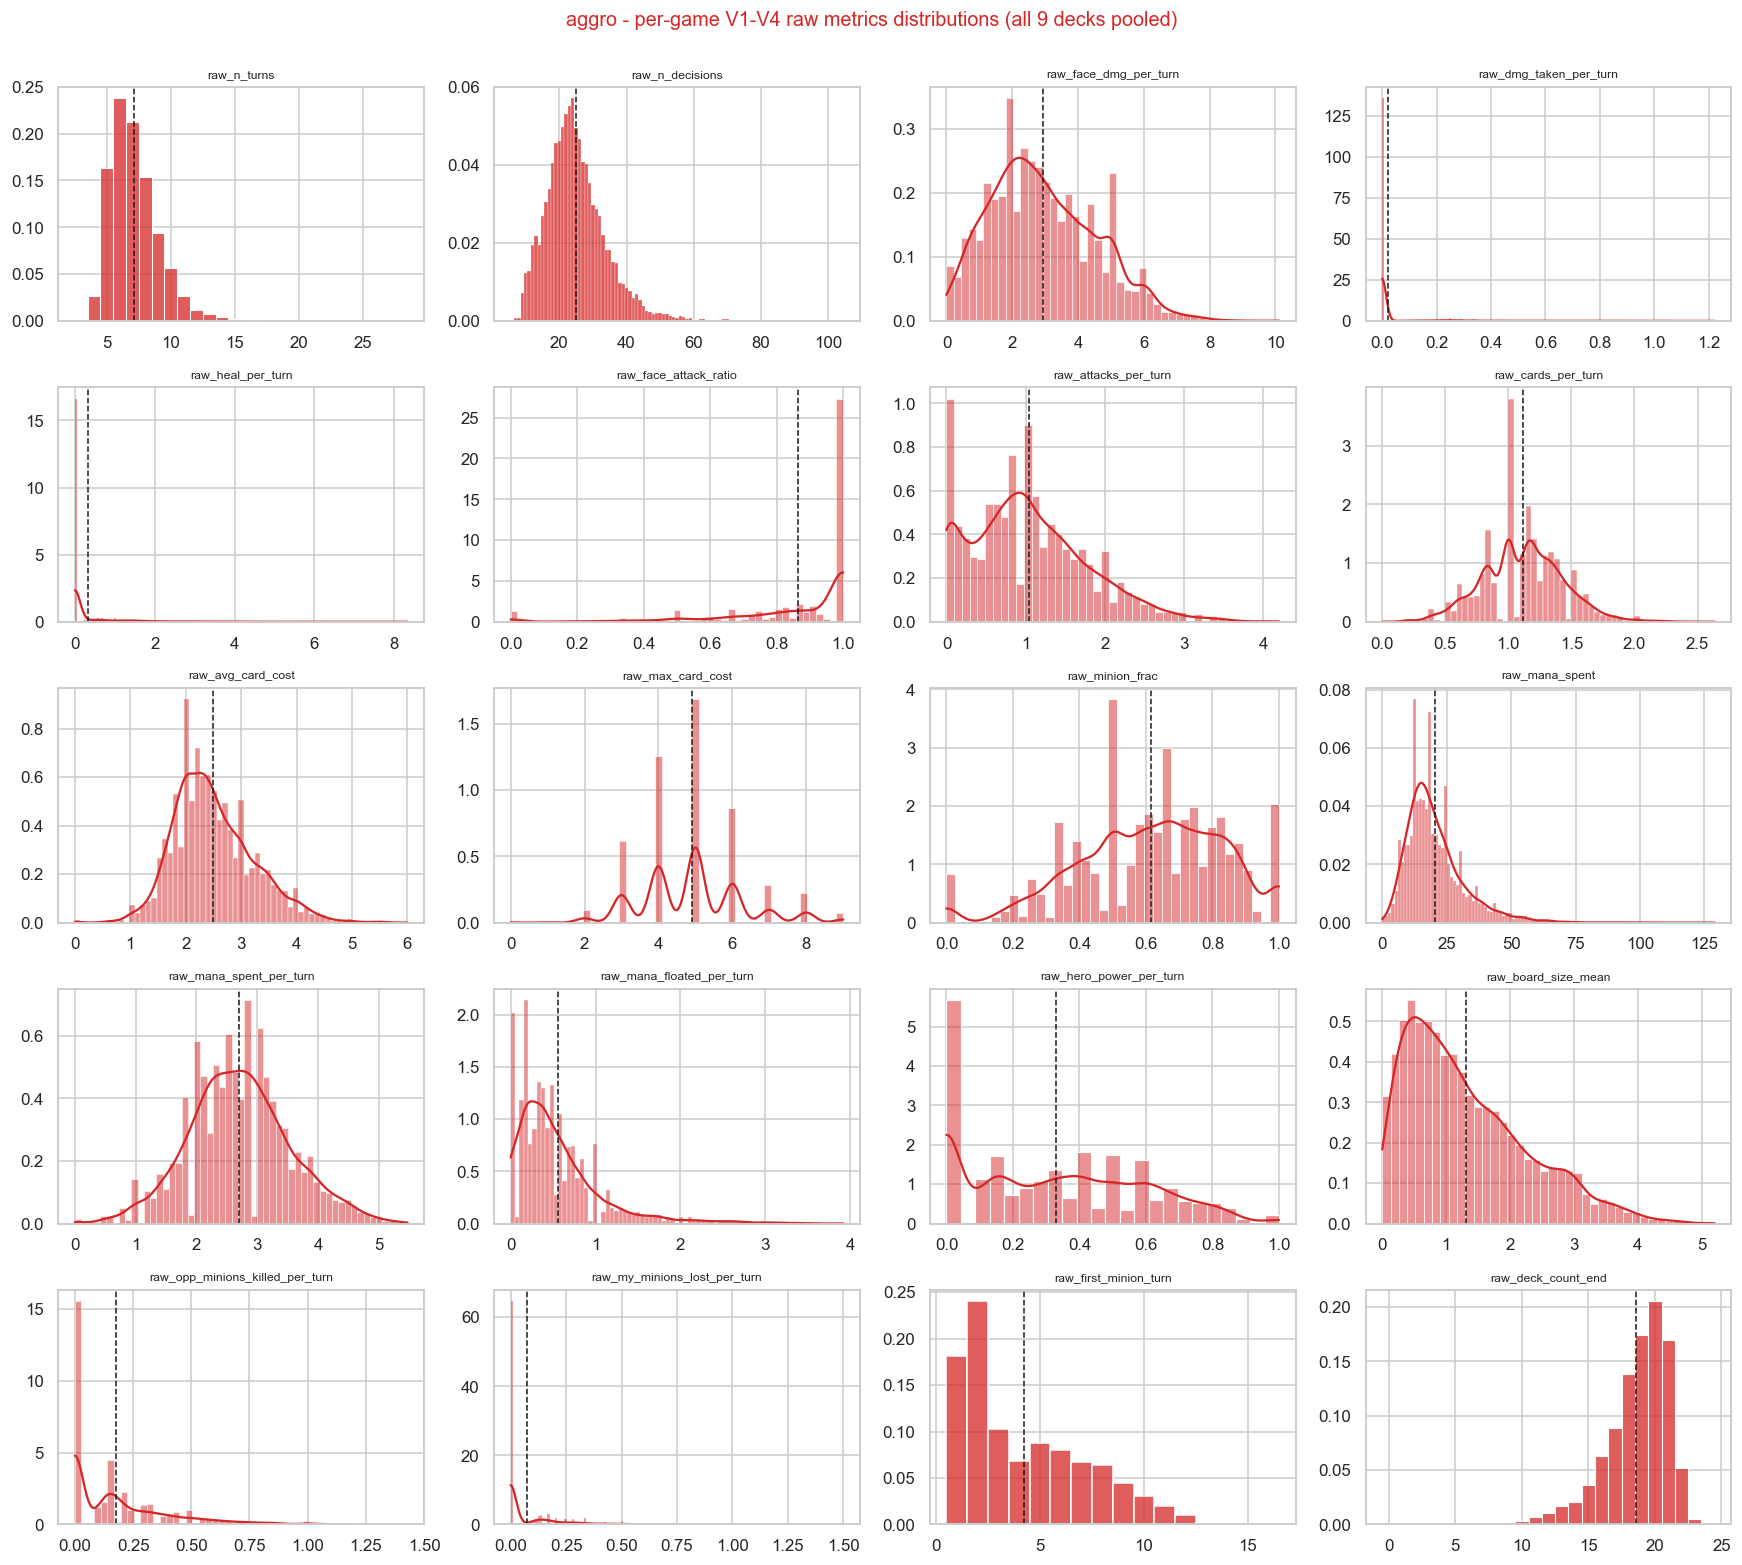

In [3]:
show_style("aggro")

### `control`  -  8099 games  -  win 54.3%  -  avg 9.0 turns

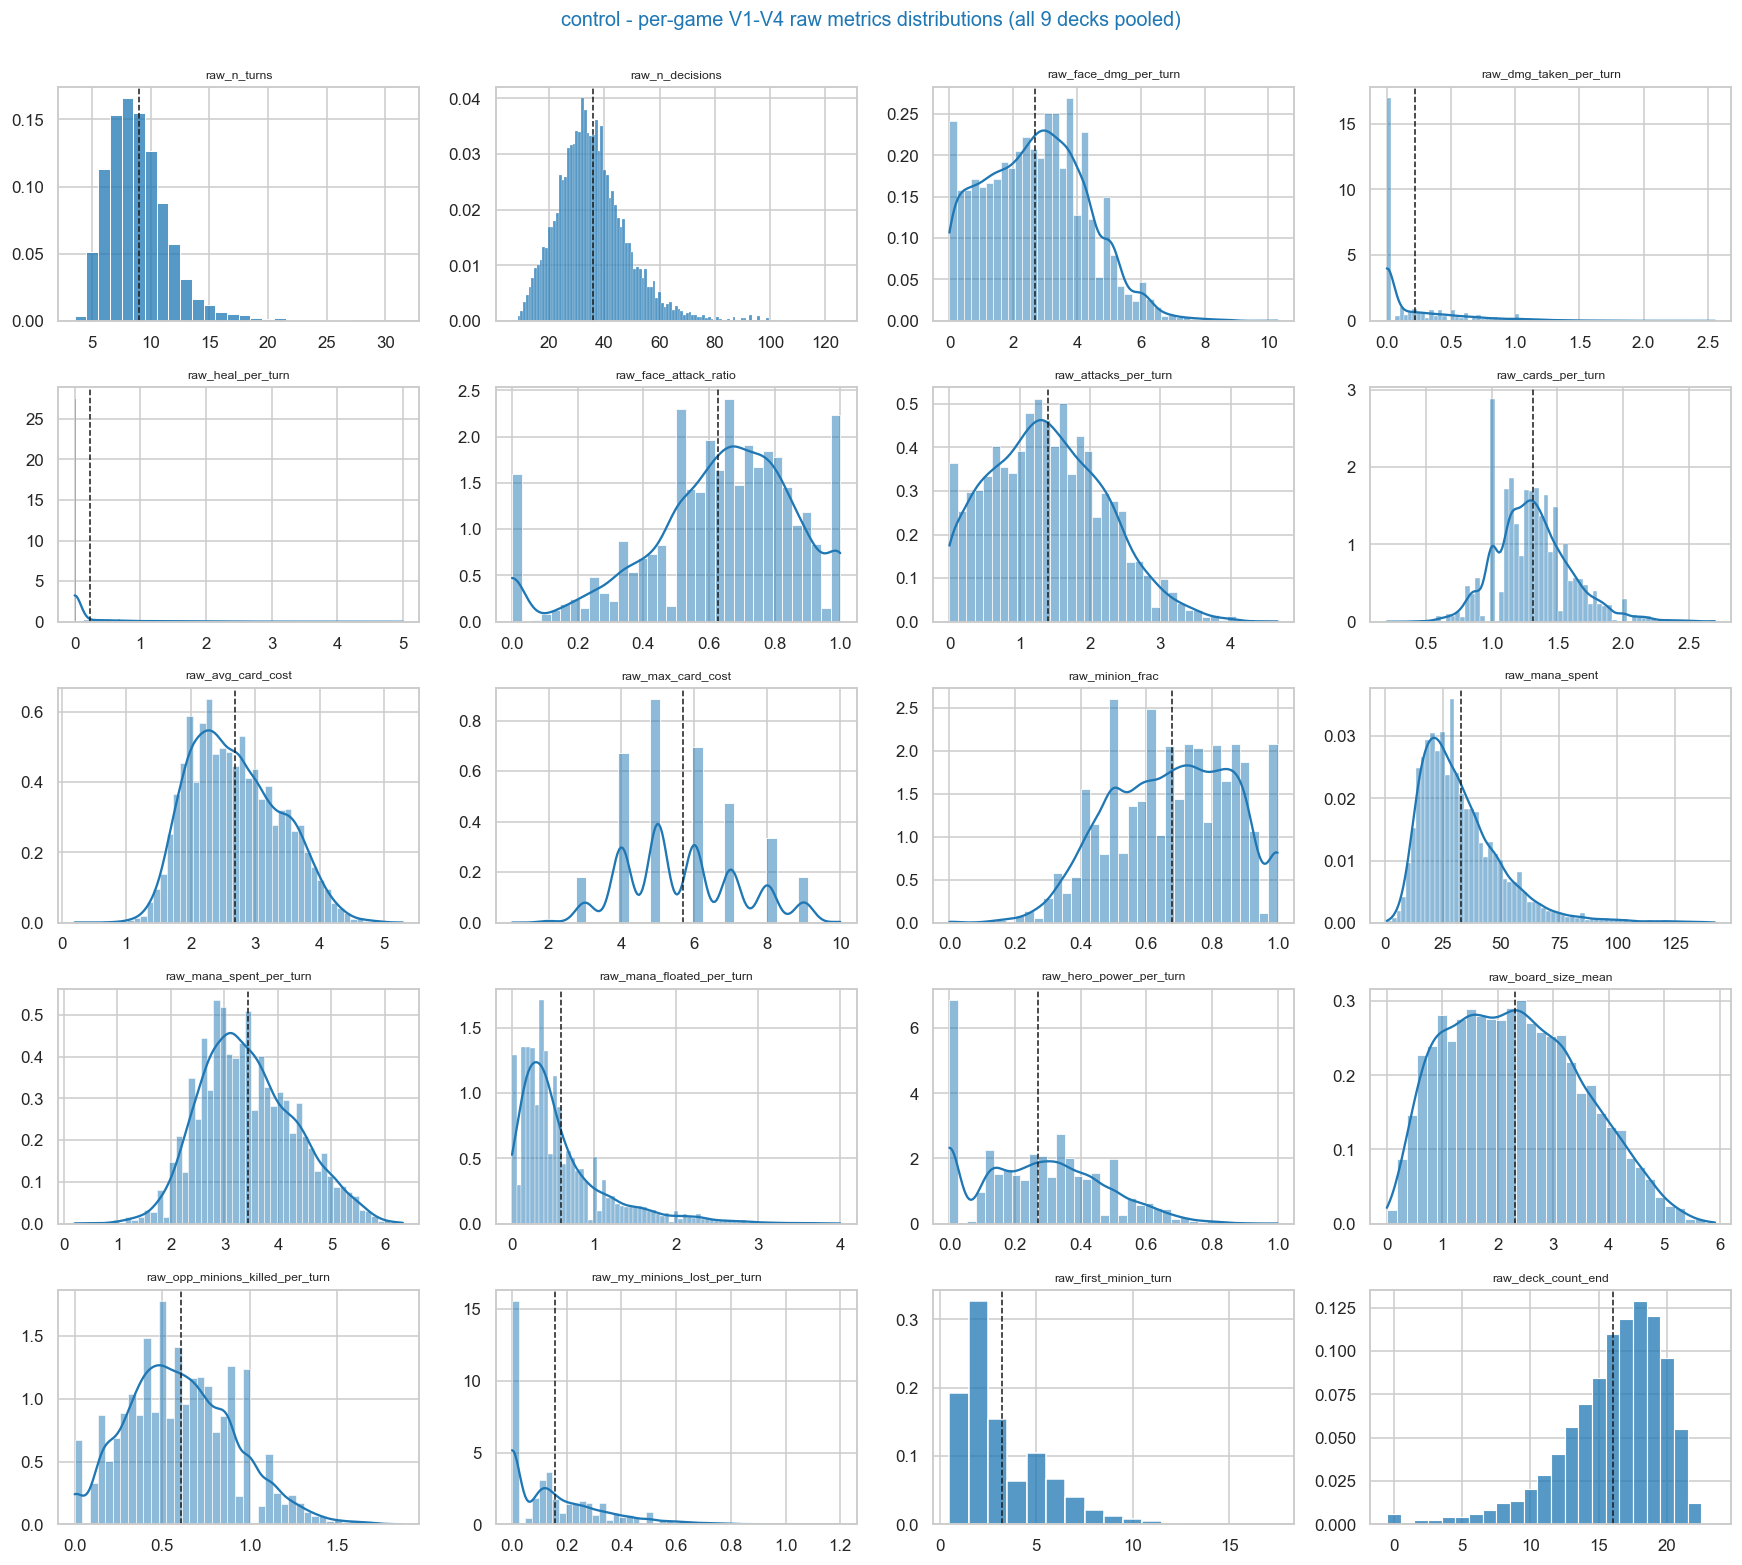

In [4]:
show_style("control")

### `fatigue`  -  8100 games  -  win 41.8%  -  avg 8.4 turns

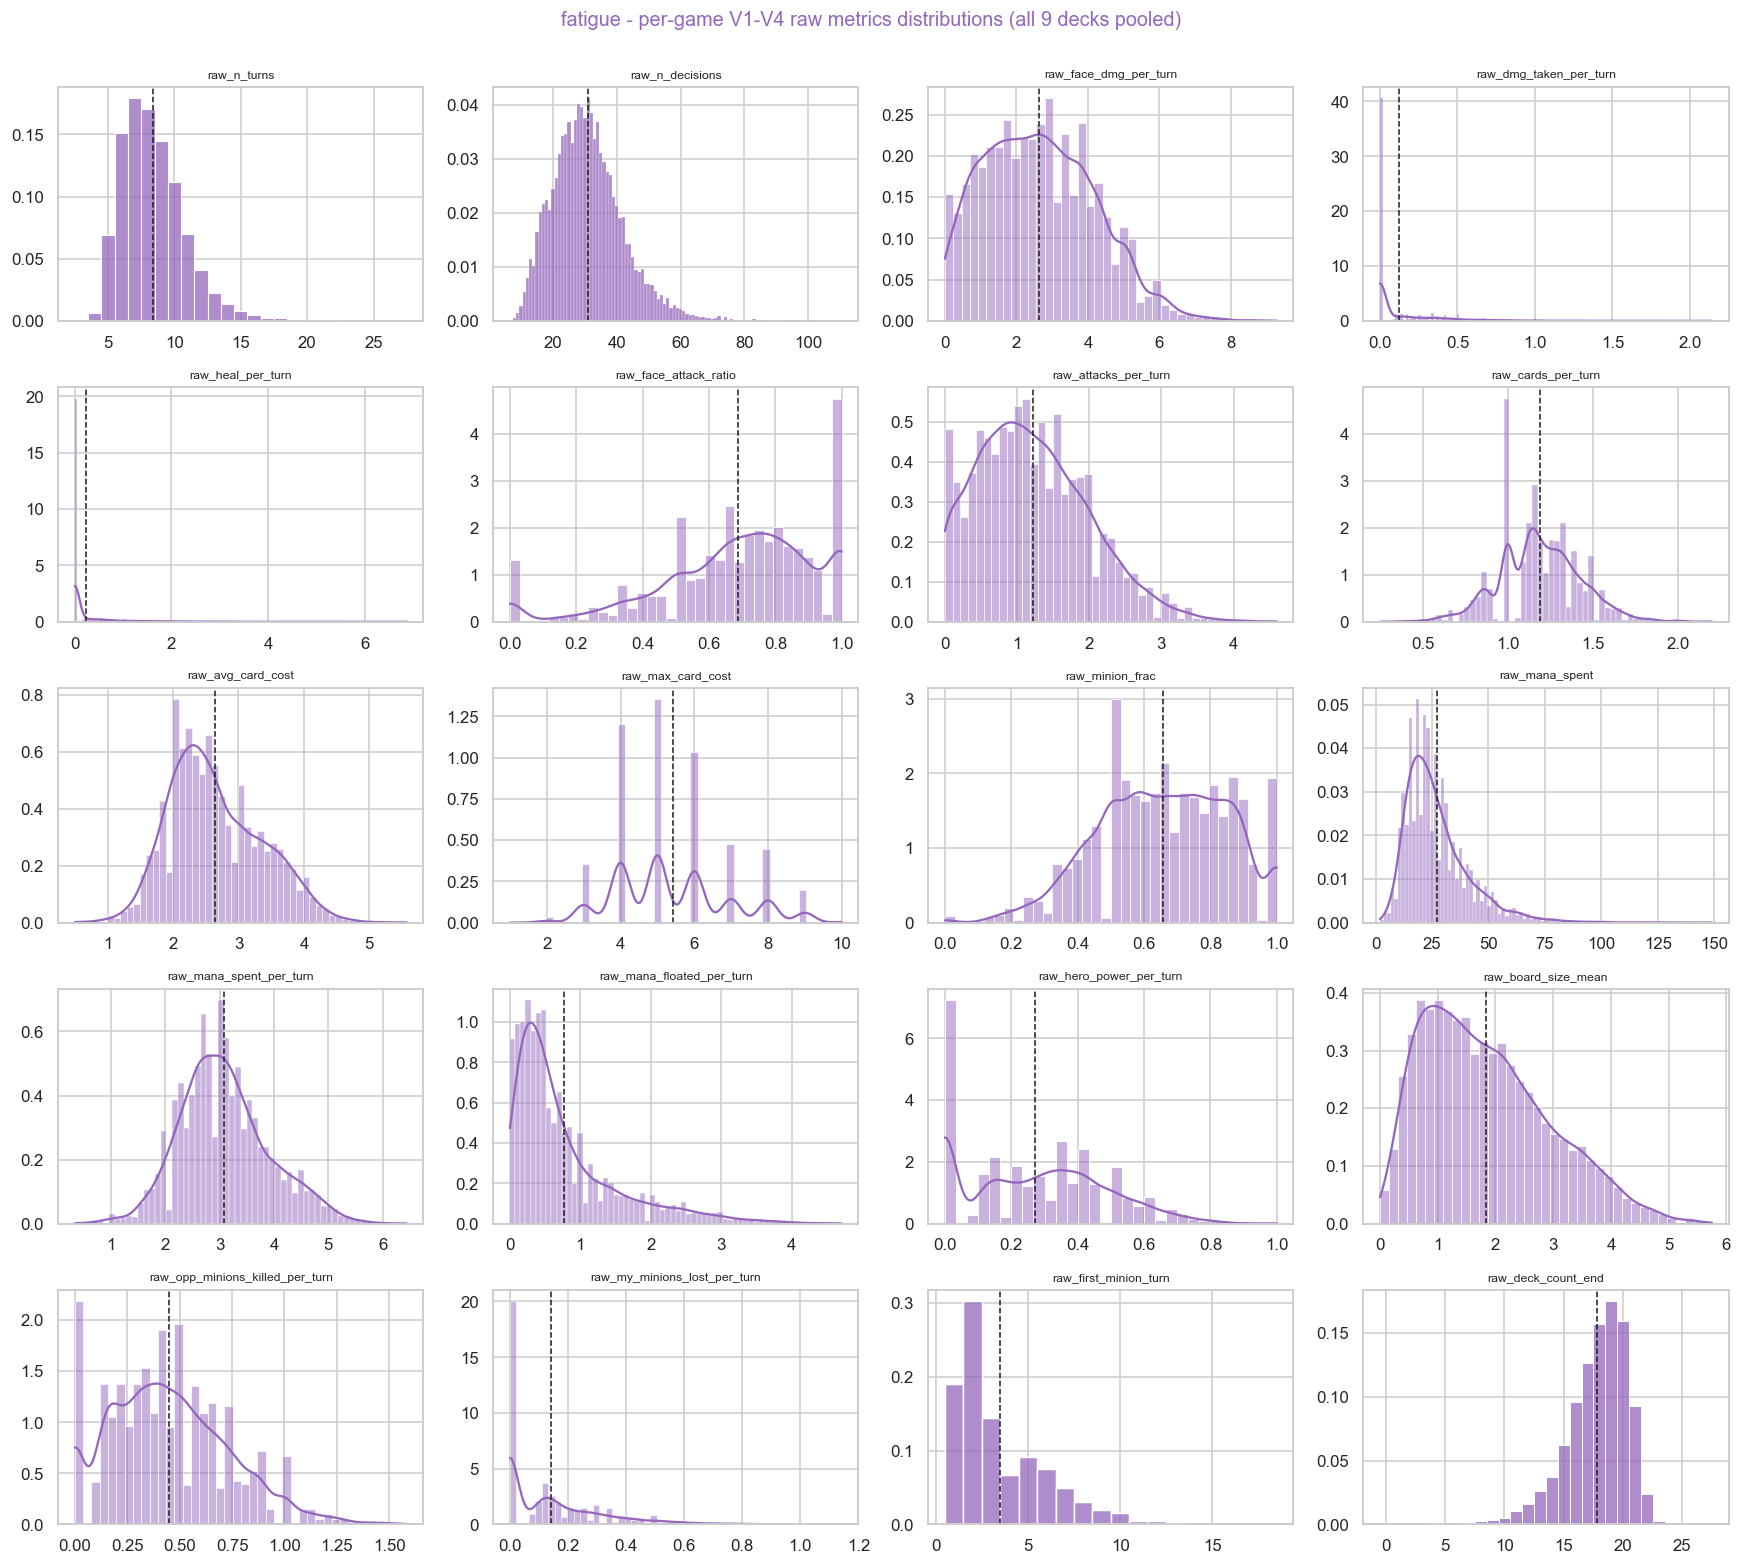

In [5]:
show_style("fatigue")

### `midrange`  -  8097 games  -  win 61.8%  -  avg 8.7 turns

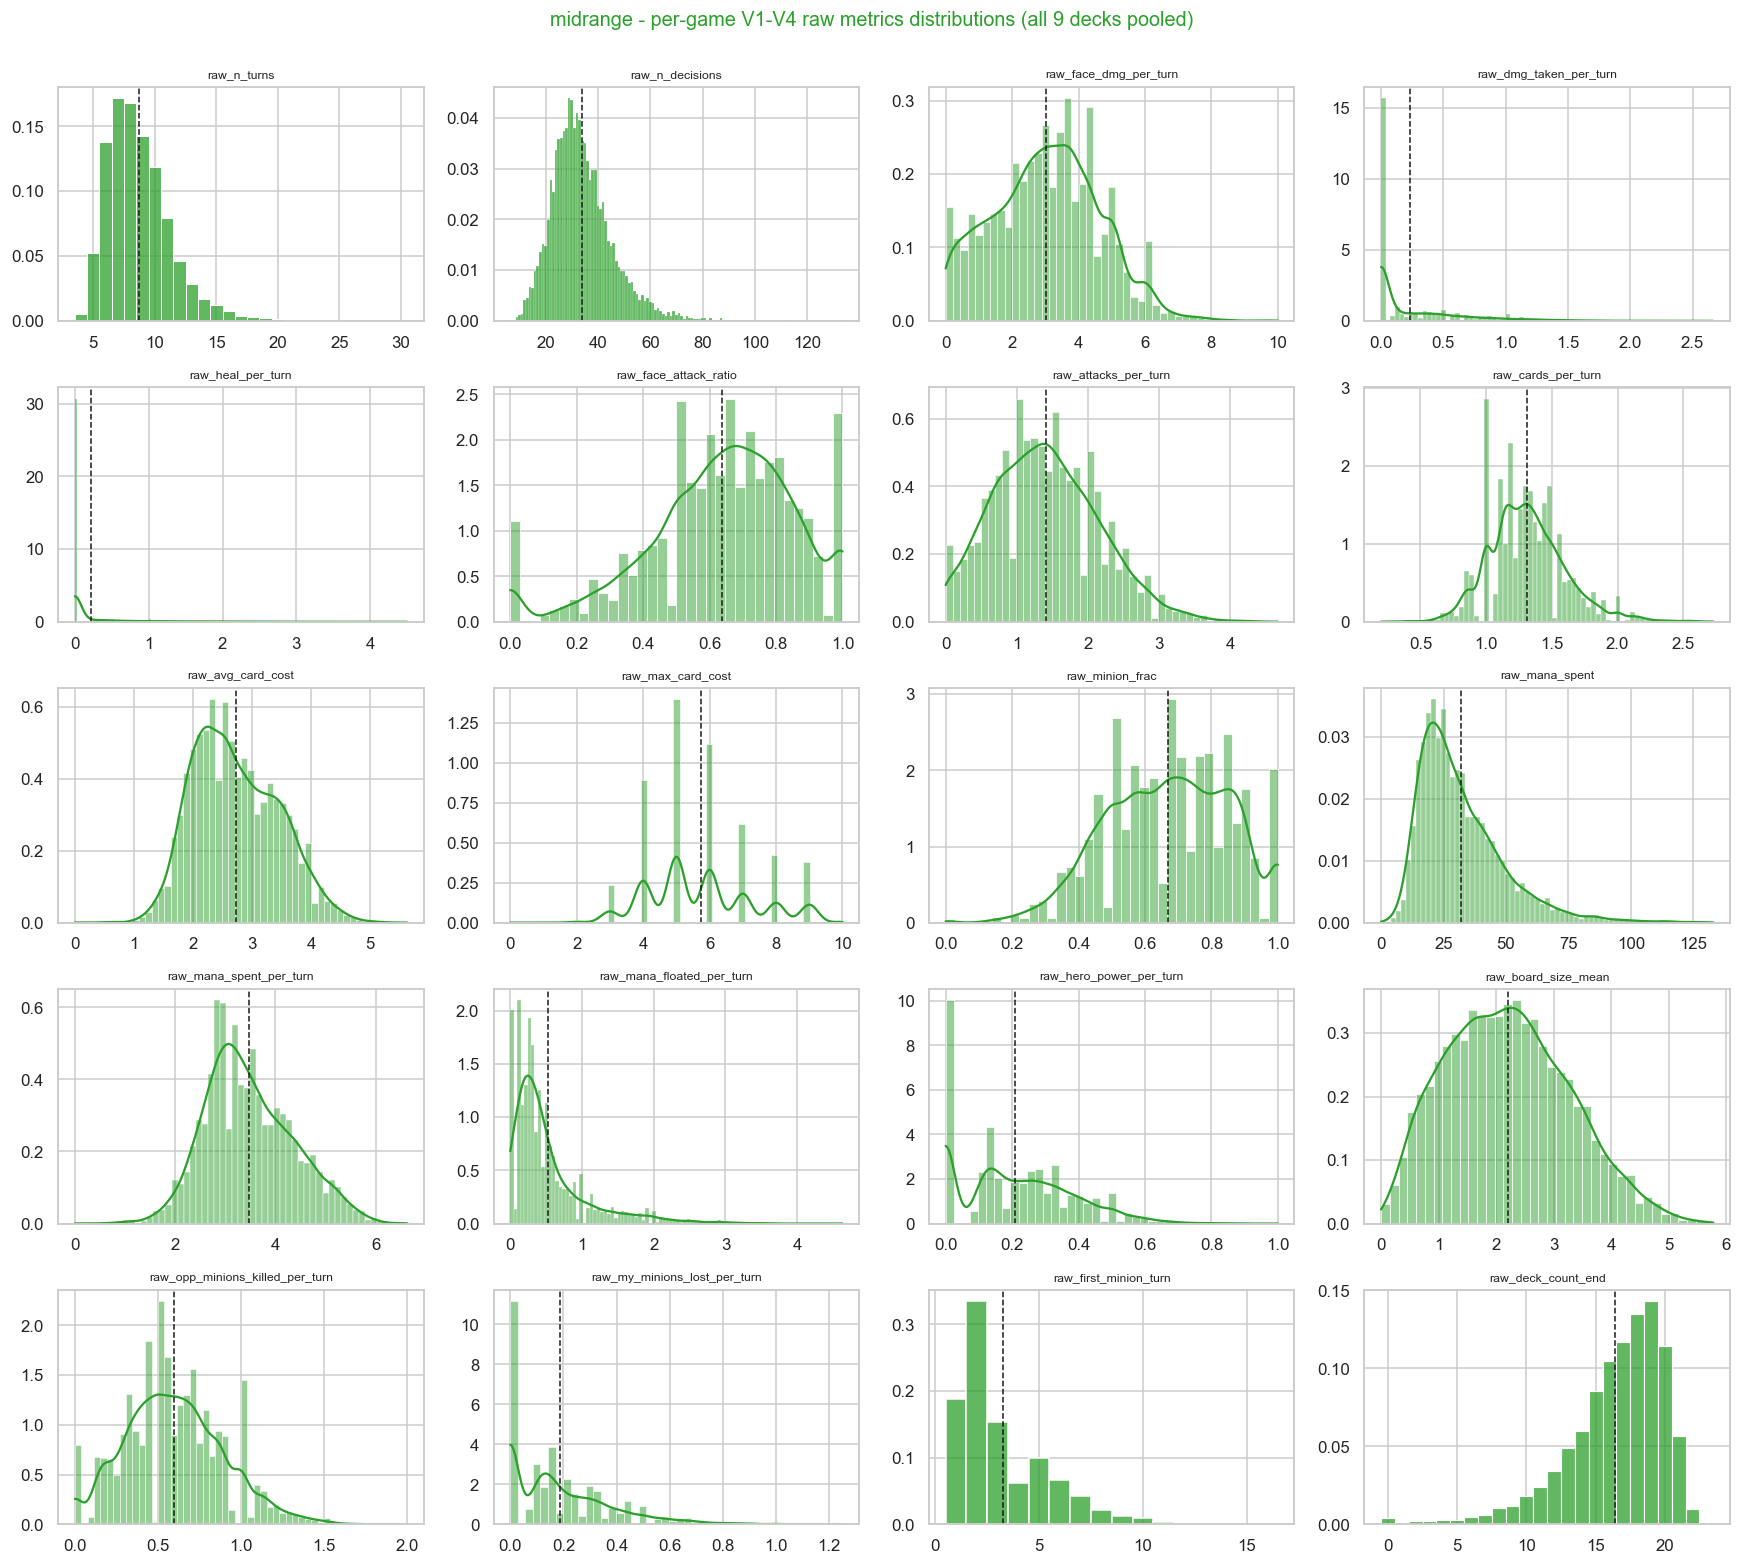

In [6]:
show_style("midrange")

### `ramp`  -  8096 games  -  win 63.5%  -  avg 9.3 turns

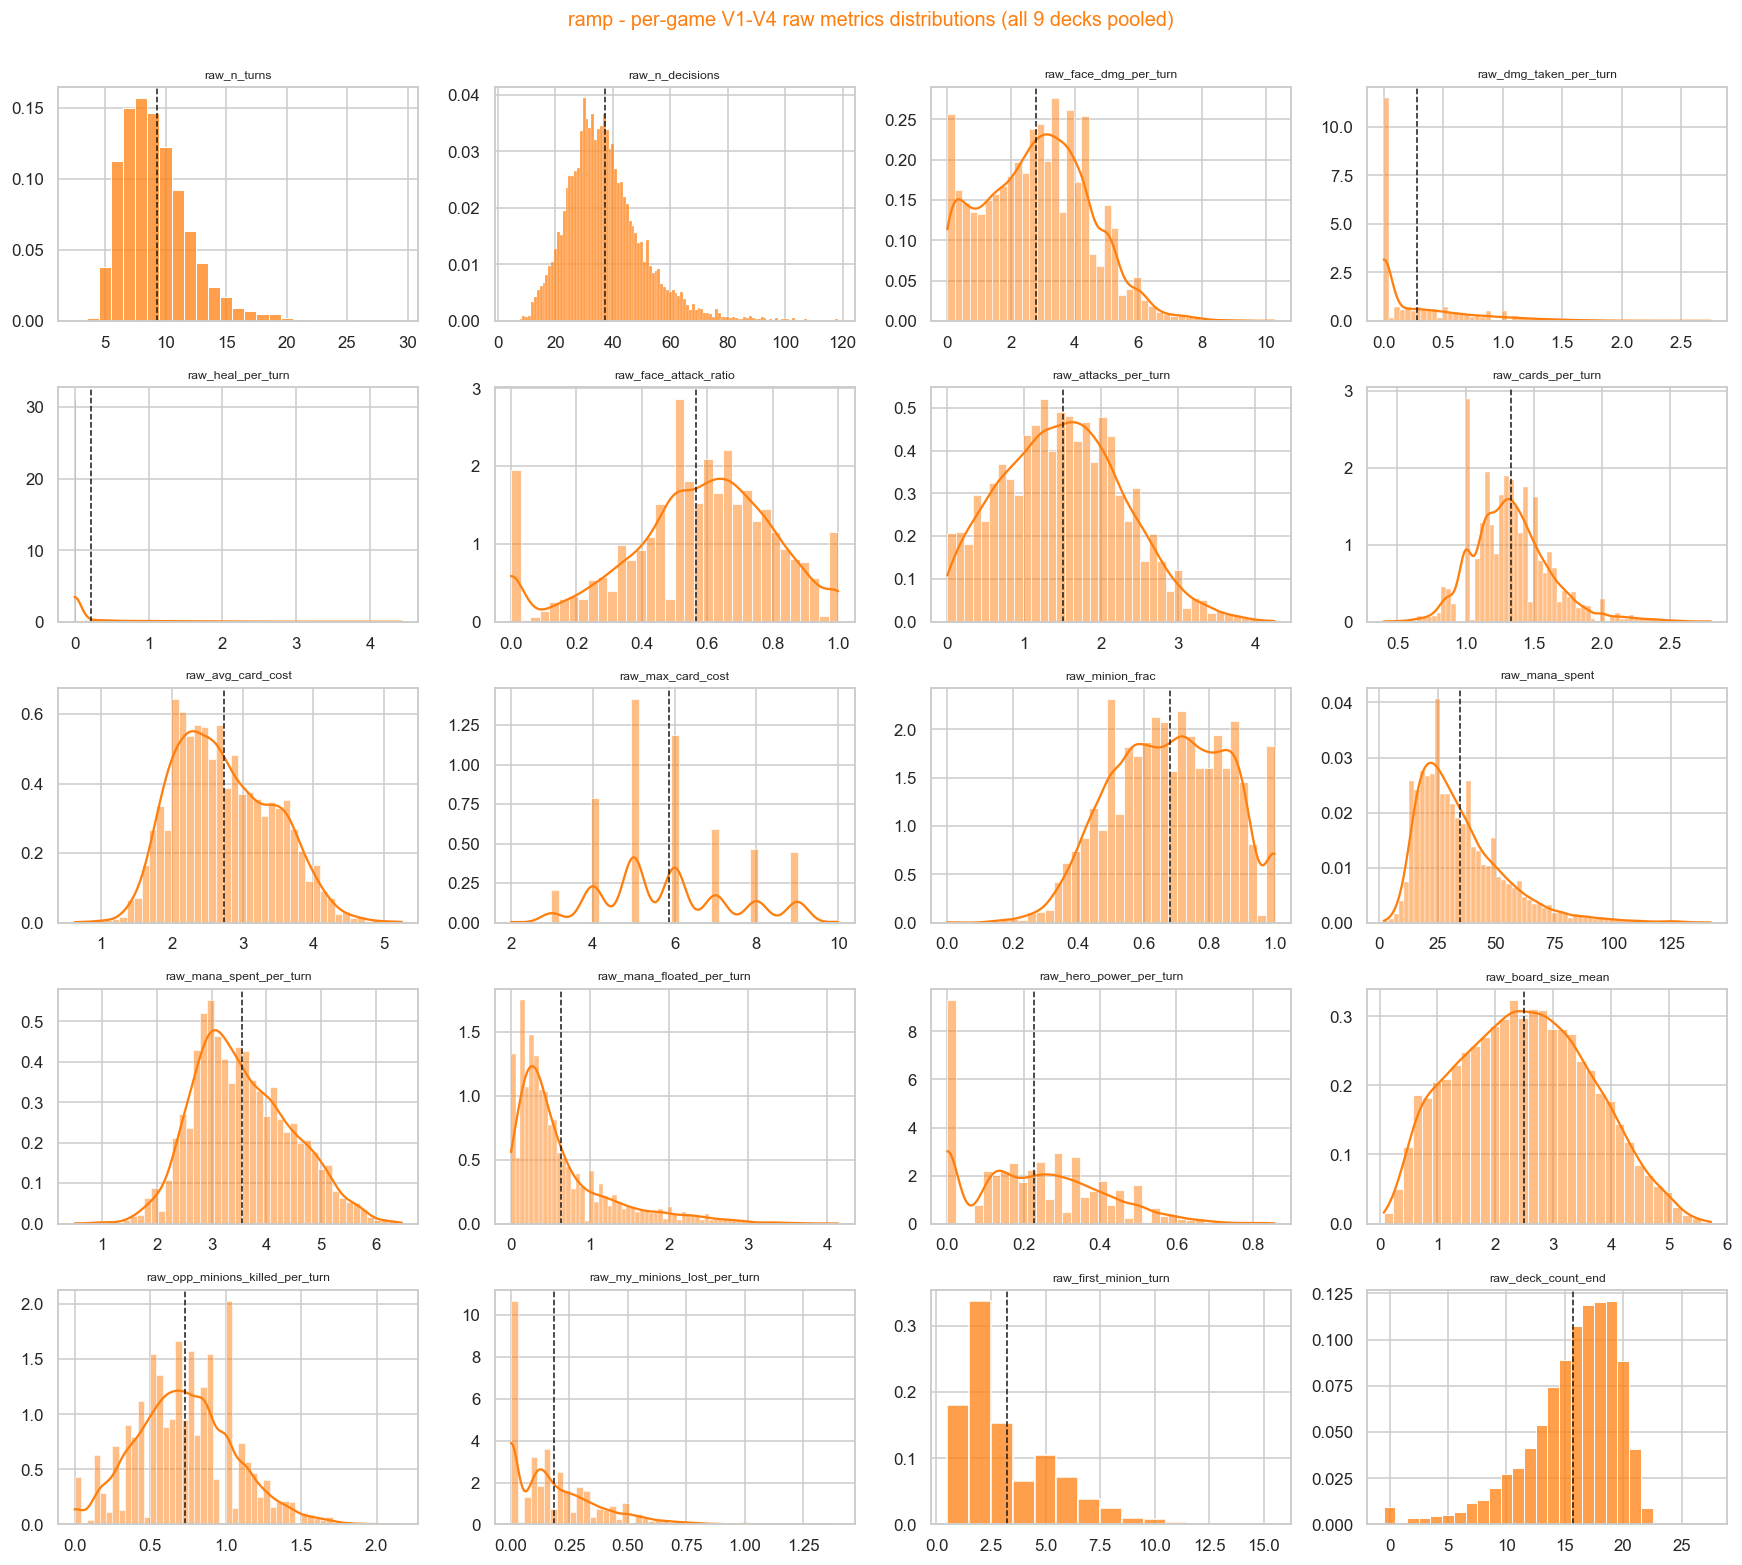

In [7]:
show_style("ramp")

## 3 - Overlaid distributions - all 5 styles per metric

For each metric, all 5 styles' KDEs share one axis; where the coloured curves pull apart the metric carries play-style signal, where they overlap it does not. The heatmap below is the multivariate fingerprint: each style's mean vector, z-scored across the 5 styles.

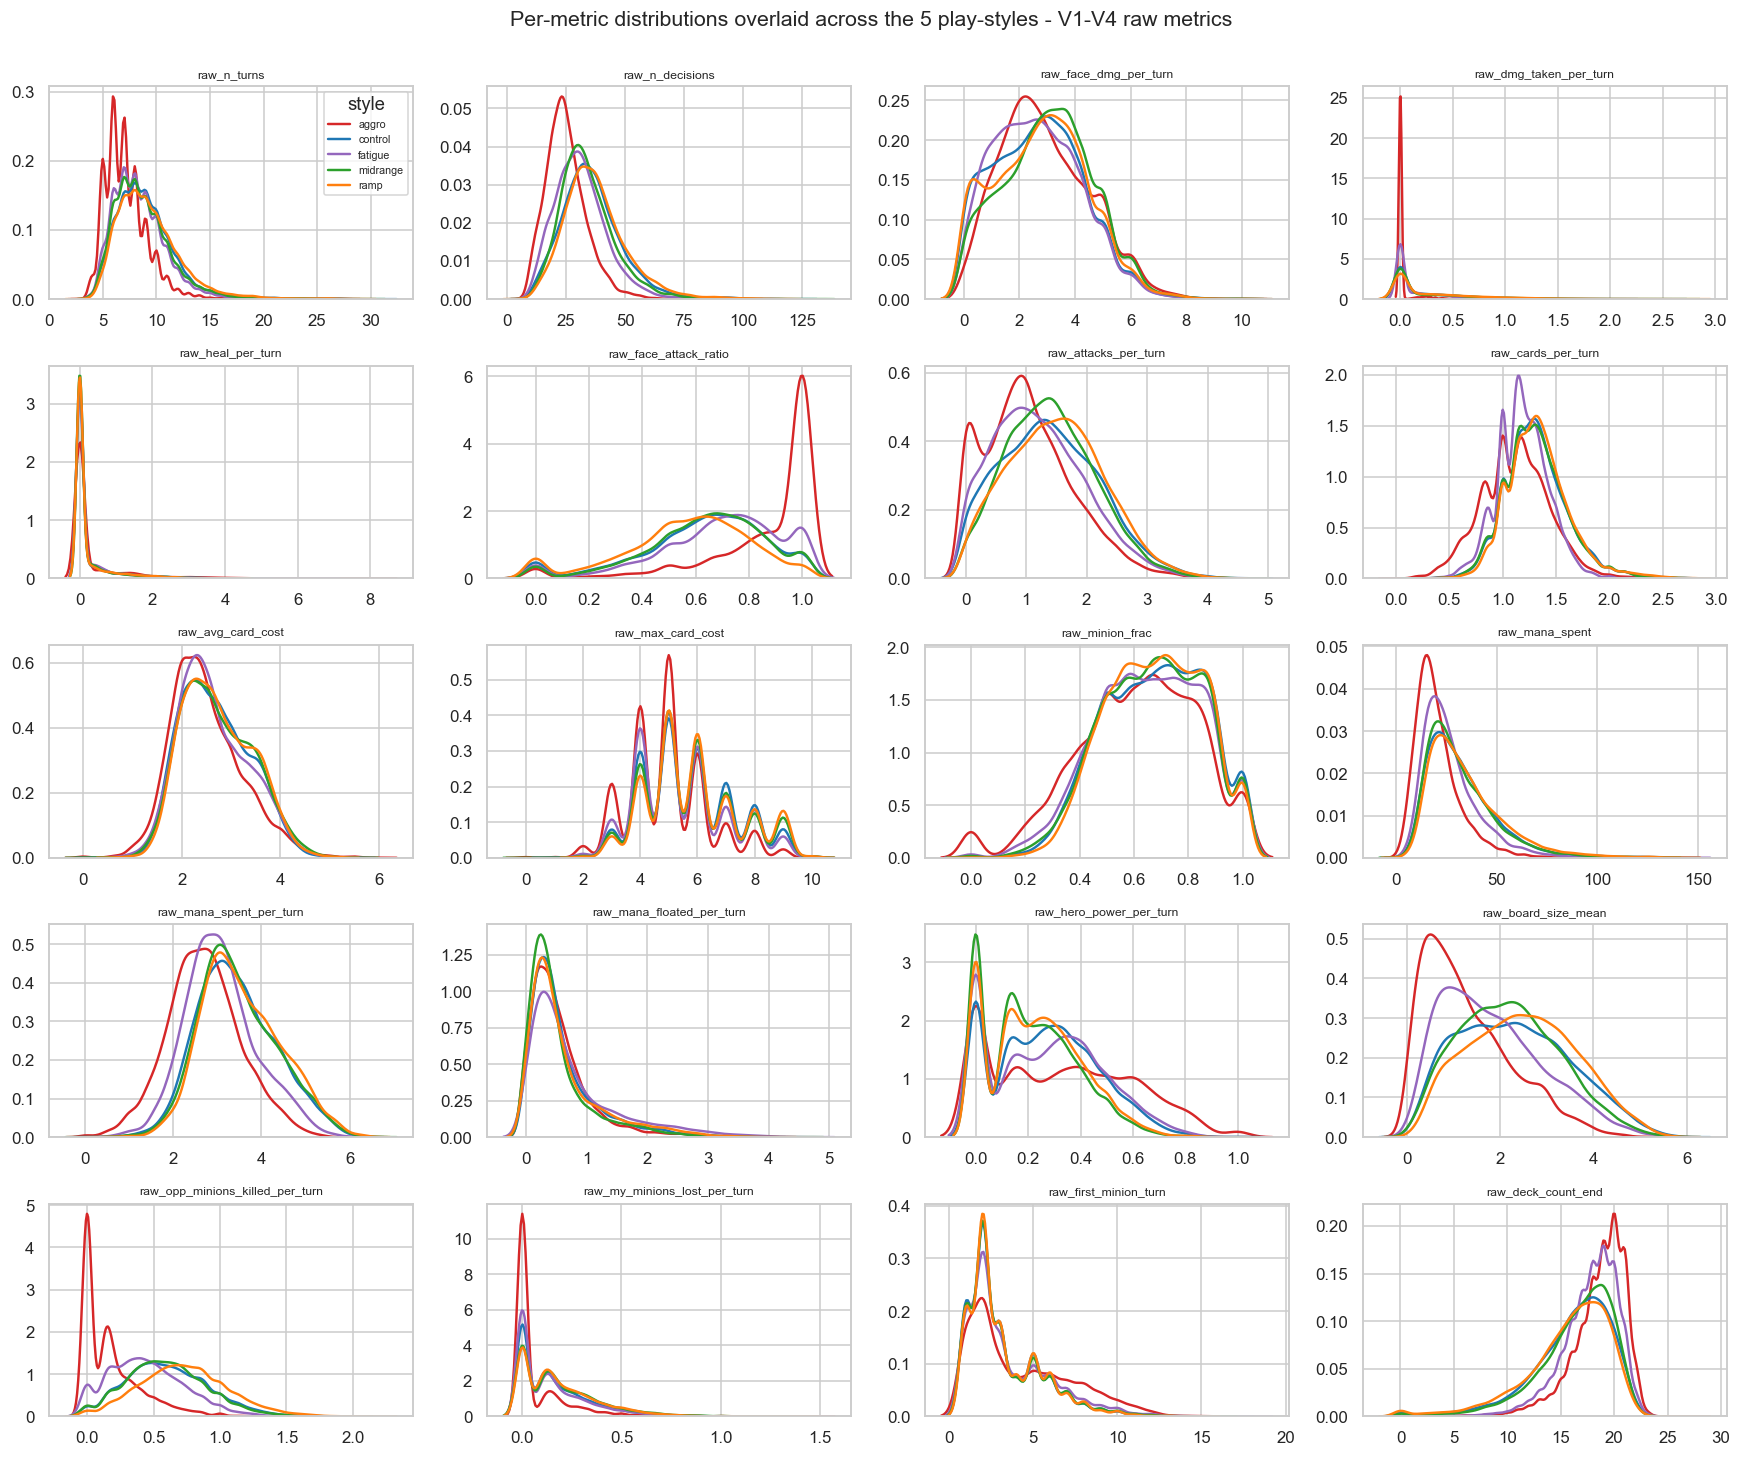

,raw_n_turns,raw_n_decisions,raw_face_dmg_per_turn,raw_dmg_taken_per_turn,raw_heal_per_turn,raw_face_attack_ratio,raw_attacks_per_turn,raw_cards_per_turn,raw_avg_card_cost,raw_max_card_cost,raw_minion_frac,raw_mana_spent,raw_mana_spent_per_turn,raw_mana_floated_per_turn,raw_hero_power_per_turn,raw_board_size_mean,raw_opp_minions_killed_per_turn,raw_my_minions_lost_per_turn,raw_first_minion_turn,raw_deck_count_end
style,,,,,,,,,,,,,,,,,,,,
aggro,7.160,24.992,2.926,0.022,0.325,0.864,1.040,1.117,2.498,4.915,0.614,20.540,2.705,0.552,0.329,1.310,0.176,0.074,4.238,18.611
control,8.987,35.741,2.687,0.220,0.235,0.629,1.396,1.315,2.683,5.676,0.677,32.695,3.444,0.598,0.270,2.311,0.605,0.156,3.237,16.049
fatigue,8.411,31.057,2.639,0.126,0.237,0.688,1.216,1.189,2.647,5.420,0.656,27.243,3.086,0.764,0.270,1.840,0.448,0.143,3.484,17.775
midrange,8.722,34.003,3.031,0.235,0.213,0.636,1.406,1.311,2.723,5.743,0.671,31.961,3.475,0.531,0.210,2.202,0.597,0.186,3.251,16.420
ramp,9.259,37.405,2.800,0.281,0.222,0.565,1.497,1.335,2.734,5.860,0.679,34.776,3.563,0.629,0.227,2.497,0.729,0.185,3.241,15.670


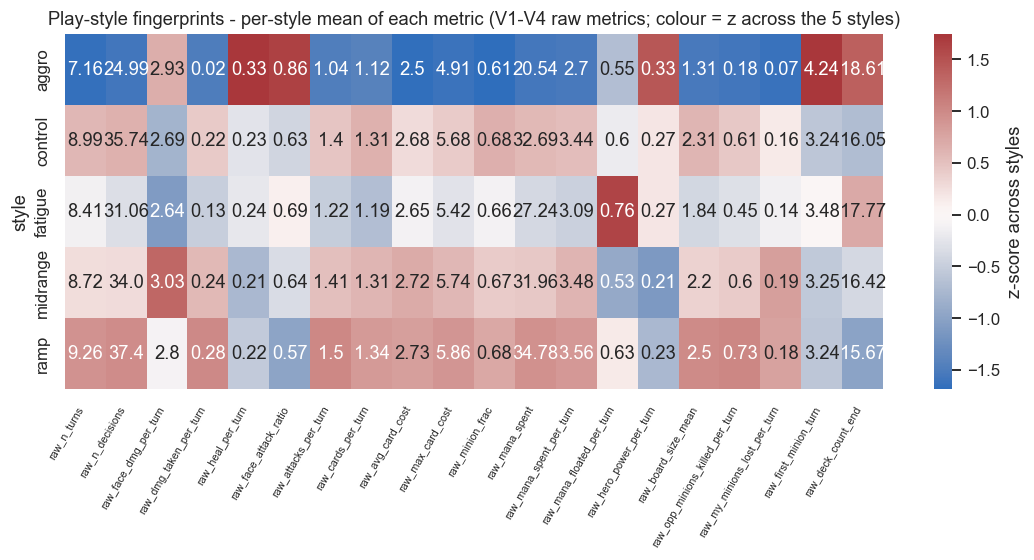

In [8]:
nrow, ncol = _grid_shape(len(GRID_METRICS))
fig, axes = plt.subplots(nrow, ncol, figsize=(4 * ncol, 2.7 * nrow)); axes = np.atleast_1d(axes).ravel()
for ax, col in zip(axes, GRID_METRICS):
    kind = kind_of(col)
    for st in STYLE_ORDER:
        s = df.loc[df["style"] == st, col].dropna()
        if s.nunique() > 1:
            clip = s.clip(0, 1) if kind == "clip01" else s
            sns.kdeplot(clip, ax=ax, color=STYLE_COLORS[st], lw=1.6, label=st, warn_singular=False)
    ax.set_title(col, fontsize=8); ax.set_xlabel(""); ax.set_ylabel("")
for ax in axes[len(GRID_METRICS):]:
    ax.axis("off")
axes[0].legend(title="style", fontsize=7)
fig.suptitle(f"Per-metric distributions overlaid across the 5 play-styles - {BLOCK_LABEL}", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.98]); plt.show()

# per-style fingerprint: mean of each model feature, z-scored across the 5 styles
mean_tbl = df.groupby("style", observed=True)[FEATURES].mean().reindex(STYLE_ORDER)
z = (mean_tbl - mean_tbl.mean()) / mean_tbl.std()
display(mean_tbl.round(3))
fig, ax = plt.subplots(figsize=(max(10, 0.6 * len(FEATURES)), 4.2))
sns.heatmap(z, annot=mean_tbl.round(2), fmt="", cmap="vlag", center=0, ax=ax,
            cbar_kws={"label": "z-score across styles"})
ax.set_title(f"Play-style fingerprints - per-style mean of each metric ({BLOCK_LABEL}; colour = z across the 5 styles)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=60, ha="right", fontsize=7)
plt.show()

### 3b - Deck sensitivity of the metrics *(adapted)*

`features.csv` is one row per game (no per-turn trace), so V4's SS 3b turn-trajectories are not reconstructable here. In their place is the question that decides this whole study: **does each metric order the 5 styles the same way on every deck?** One thin line per deck, black dashed = the mean profile. **Parallel** lines mean the style signal is deck-robust (what the choice block is designed for); **crossing** lines mean the metric is deck-entangled (the raw block's weakness) - previewing SS 9.

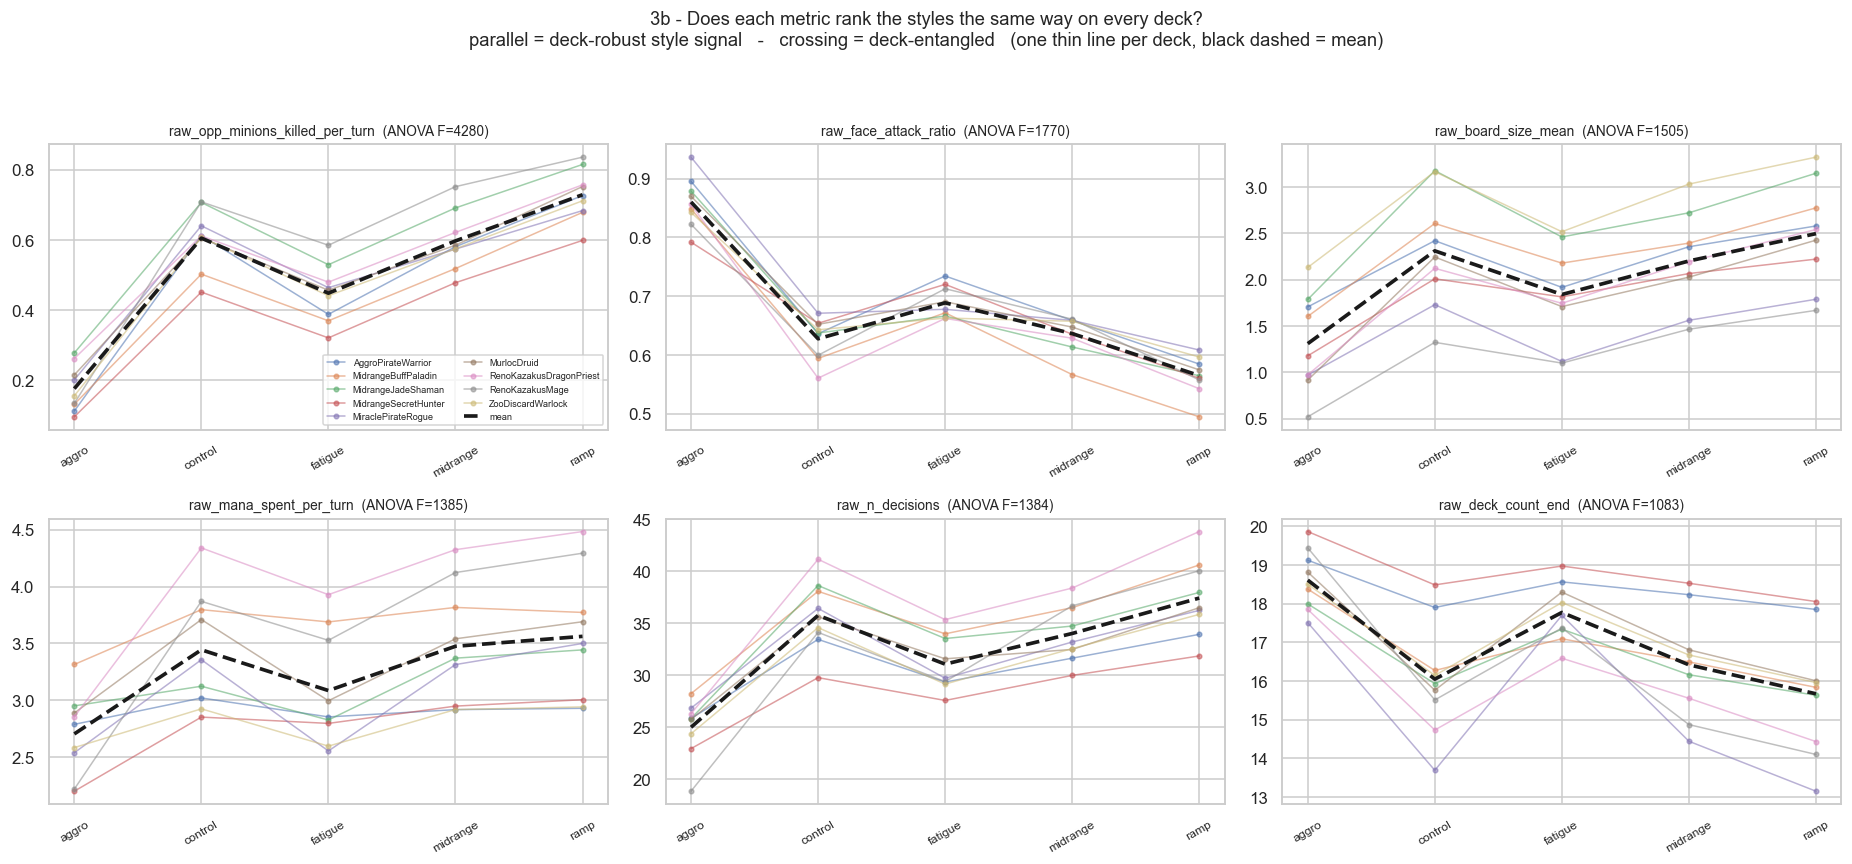

In [9]:
# features.csv is per-GAME (no per-turn trajectory), so in place of V4's SS 3b turn-curves we ask the
# question that matters most for THIS block: does each metric rank the 5 styles the SAME way on every
# deck? Parallel lines across decks = a deck-robust style signal; crossing lines = deck-entangled.
from scipy.stats import f_oneway

def anova_F(col):
    groups = [df.loc[df["style"] == s, col].dropna().values for s in STYLE_ORDER]
    groups = [g for g in groups if len(g) > 1]
    if len(groups) < 2:
        return 0.0
    try:
        return float(f_oneway(*groups).statistic)
    except Exception:
        return 0.0

Fs = pd.Series({c: anova_F(c) for c in FEATURES}).sort_values(ascending=False)
top = list(Fs.head(6).index)

fig, axes = plt.subplots(2, 3, figsize=(17, 8)); axes = axes.ravel()
for ax, col in zip(axes, top):
    piv = df.pivot_table(index="style", columns="deck", values=col, observed=True).reindex(STYLE_ORDER)
    for deck in piv.columns:
        ax.plot(range(len(STYLE_ORDER)), piv[deck].values, marker="o", ms=3, lw=1, alpha=.55, label=deck)
    ax.plot(range(len(STYLE_ORDER)), piv.mean(axis=1).values, "k--", lw=2.4, label="mean")
    ax.set_xticks(range(len(STYLE_ORDER))); ax.set_xticklabels(STYLE_ORDER, rotation=30, fontsize=8)
    ax.set_title(f"{col}  (ANOVA F={Fs[col]:.0f})", fontsize=9)
axes[0].legend(fontsize=6, ncol=2)
fig.suptitle("3b - Does each metric rank the styles the same way on every deck?\n"
             "parallel = deck-robust style signal   -   crossing = deck-entangled   "
             "(one thin line per deck, black dashed = mean)", fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.94]); plt.show()

## 4 - Feature matrix (standardised)

Stack the per-game metrics into `X` (median-imputed, then z-scored). `y` is the true style. This matrix feeds every model from SS 5 on.

In [10]:
from sklearn.preprocessing import StandardScaler

X_raw = df[FEATURES].copy()
X_raw = X_raw.fillna(X_raw.median())
y = styles_of(df)
scaler = StandardScaler().fit(X_raw.values)
X = scaler.transform(X_raw.values)
print(f"feature matrix: {X.shape}  ({len(FEATURES)} {BLOCK_LABEL})")
print("features:", ", ".join(FEATURES))

feature matrix: (40492, 20)  (20 V1-V4 raw metrics)
features: raw_n_turns, raw_n_decisions, raw_face_dmg_per_turn, raw_dmg_taken_per_turn, raw_heal_per_turn, raw_face_attack_ratio, raw_attacks_per_turn, raw_cards_per_turn, raw_avg_card_cost, raw_max_card_cost, raw_minion_frac, raw_mana_spent, raw_mana_spent_per_turn, raw_mana_floated_per_turn, raw_hero_power_per_turn, raw_board_size_mean, raw_opp_minions_killed_per_turn, raw_my_minions_lost_per_turn, raw_first_minion_turn, raw_deck_count_end


## 5 - Per-game projection & clustering - the honest baseline

Project the per-game points to 2-D (**PCA**, **t-SNE**) coloured by true style, then run **unsupervised KMeans** with `k=5` and score the clusters against the true styles with **ARI** (chance line 0.20). Expectation: at the **single-game** level, pooled over 9 decks and random opponents, the clouds **overlap**, so ARI sits near the floor.

Per-game unsupervised clustering vs the 5 true styles (all 9 decks pooled)
  KMeans(k=5): ARI=0.038   (chance = 0.20)


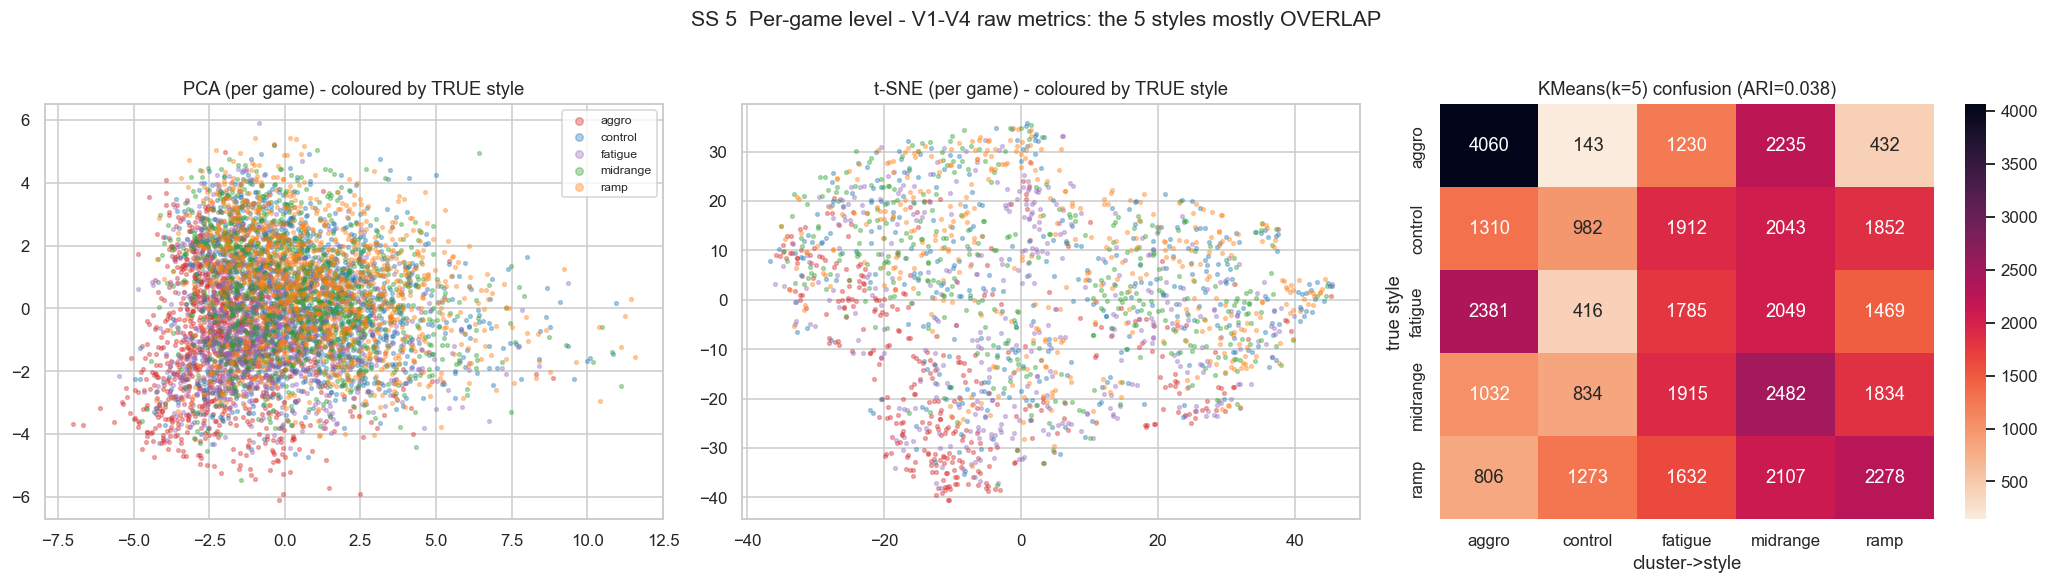

In [11]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from scipy.optimize import linear_sum_assignment

# MODEL POLICY (whole notebook): unsupervised = KMeans, supervised = LDA, metric = ARI.

def cluster_confusion(true_lab, clab, order=STYLE_ORDER):
    # map cluster ids to styles (Hungarian on the contingency table) -> readable confusion matrix
    k = len(order)
    M = pd.crosstab(pd.Series(true_lab, name="style"), pd.Series(clab, name="cluster"))
    M = M.reindex(index=order).reindex(columns=range(k), fill_value=0).fillna(0)
    r, c = linear_sum_assignment(-M.values)
    col_to_style = {c[i]: order[r[i]] for i in range(len(r))}
    mapped = pd.Series(clab).map(lambda x: col_to_style.get(x, x)).values
    cm = pd.crosstab(pd.Series(true_lab, name="true style"),
                     pd.Series(mapped, name="cluster->style")).reindex(index=order, columns=order, fill_value=0)
    return cm, mapped

rng = np.random.default_rng(0)
pca = PCA(n_components=2, random_state=0).fit(X)
P = pca.transform(X)
sub  = rng.choice(len(X), size=min(1800, len(X)), replace=False)   # t-SNE on a subsample (speed)
psub = rng.choice(len(X), size=min(6000, len(X)), replace=False)   # scatter subsample (40k overplots)
T = TSNE(n_components=2, init="pca", perplexity=40, random_state=0).fit_transform(X[sub])

km = KMeans(5, n_init=10, random_state=0).fit(X)
km_lab = km.labels_
ari_km = adjusted_rand_score(y, km_lab)

print("Per-game unsupervised clustering vs the 5 true styles (all 9 decks pooled)")
print(f"  KMeans(k=5): ARI={ari_km:.3f}   (chance = 0.20)")

fig, ax = plt.subplots(1, 3, figsize=(19, 5.4))
for st in STYLE_ORDER:
    m  = (y[psub] == st); ax[0].scatter(P[psub][m, 0], P[psub][m, 1], s=6, alpha=.35, color=STYLE_COLORS[st], label=st)
    ms = (y[sub]  == st); ax[1].scatter(T[ms, 0], T[ms, 1], s=6, alpha=.35, color=STYLE_COLORS[st], label=st)
ax[0].set_title("PCA (per game) - coloured by TRUE style"); ax[0].legend(fontsize=8, markerscale=2)
ax[1].set_title("t-SNE (per game) - coloured by TRUE style")
cm, _ = cluster_confusion(y, km_lab)
sns.heatmap(cm, annot=True, fmt="d", cmap="rocket_r", ax=ax[2])
ax[2].set_title(f"KMeans(k=5) confusion (ARI={ari_km:.3f})")
for a in ax[:2]:
    a.set_xlabel(""); a.set_ylabel("")
fig.suptitle(f"SS 5  Per-game level - {BLOCK_LABEL}: the 5 styles mostly OVERLAP", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()

### 5b - Are the styles distinguishable *at all*? (supervised check)

Fit a **supervised LDA** (5-fold cross-validated predictions) and score the same way, with **ARI**. An ARI clearly above the chance line means the per-game signal is real, only noisy. Because `X` is z-scored, the LDA coefficients are comparable across features: the bar chart ranks them by **mean |coefficient| over the 5 classes**, the LDA analogue of a feature-importance plot.

LDA 5-fold CV ARI: 0.123   (chance = 0.20)   [20 V1-V4 raw metrics]


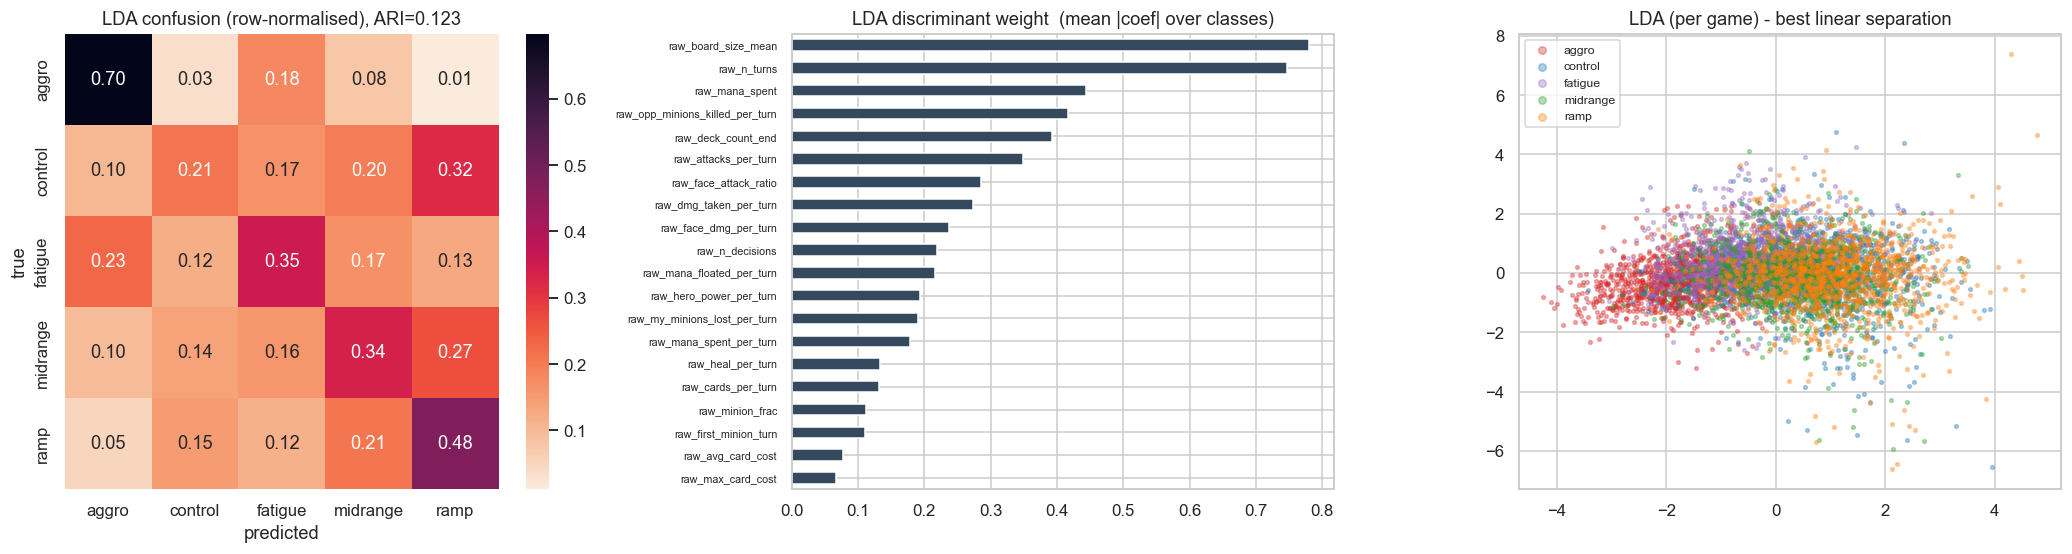

In [12]:
from sklearn.model_selection import cross_val_predict
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import adjusted_rand_score, confusion_matrix

lda = LinearDiscriminantAnalysis()
pred = cross_val_predict(lda, X, y, cv=5, n_jobs=-1)
ari = adjusted_rand_score(y, pred)
print(f"LDA 5-fold CV ARI: {ari:.3f}   (chance = 0.20)   [{len(FEATURES)} {BLOCK_LABEL}]")

fitted = LinearDiscriminantAnalysis(n_components=2).fit(X, y)
# X is z-scored, so |coef| is directly comparable across features; mean over the 5 one-vs-rest rows
# is the LDA analogue of a feature-importance ranking.
imp = pd.Series(np.abs(fitted.coef_).mean(axis=0), index=FEATURES).sort_values()
L = fitted.transform(X)

fig, ax = plt.subplots(1, 3, figsize=(19, max(5.2, 0.24 * len(FEATURES))))
cm = confusion_matrix(y, pred, labels=STYLE_ORDER, normalize="true")
sns.heatmap(pd.DataFrame(cm, index=STYLE_ORDER, columns=STYLE_ORDER), annot=True, fmt=".2f",
            cmap="rocket_r", ax=ax[0])
ax[0].set_title(f"LDA confusion (row-normalised), ARI={ari:.3f}"); ax[0].set_ylabel("true"); ax[0].set_xlabel("predicted")
imp.plot.barh(ax=ax[1], color="#34495e"); ax[1].set_title("LDA discriminant weight  (mean |coef| over classes)")
ax[1].tick_params(axis="y", labelsize=7)
Lp, yp = L[psub], y[psub]
for st in STYLE_ORDER:
    m = (yp == st); ax[2].scatter(Lp[m, 0], Lp[m, 1], s=6, alpha=.35, color=STYLE_COLORS[st], label=st)
ax[2].set_title("LDA (per game) - best linear separation"); ax[2].legend(fontsize=8, markerscale=2)
fig.tight_layout(); plt.show()

## 6 - The 5 clusters DO emerge - at the distribution level

A *play-style is a distribution over games*, not one game. Characterise each style by the distribution of its **aggregated fingerprints** (mean of N random games), cluster them **unsupervised**, and watch the 5 clouds separate as N grows.

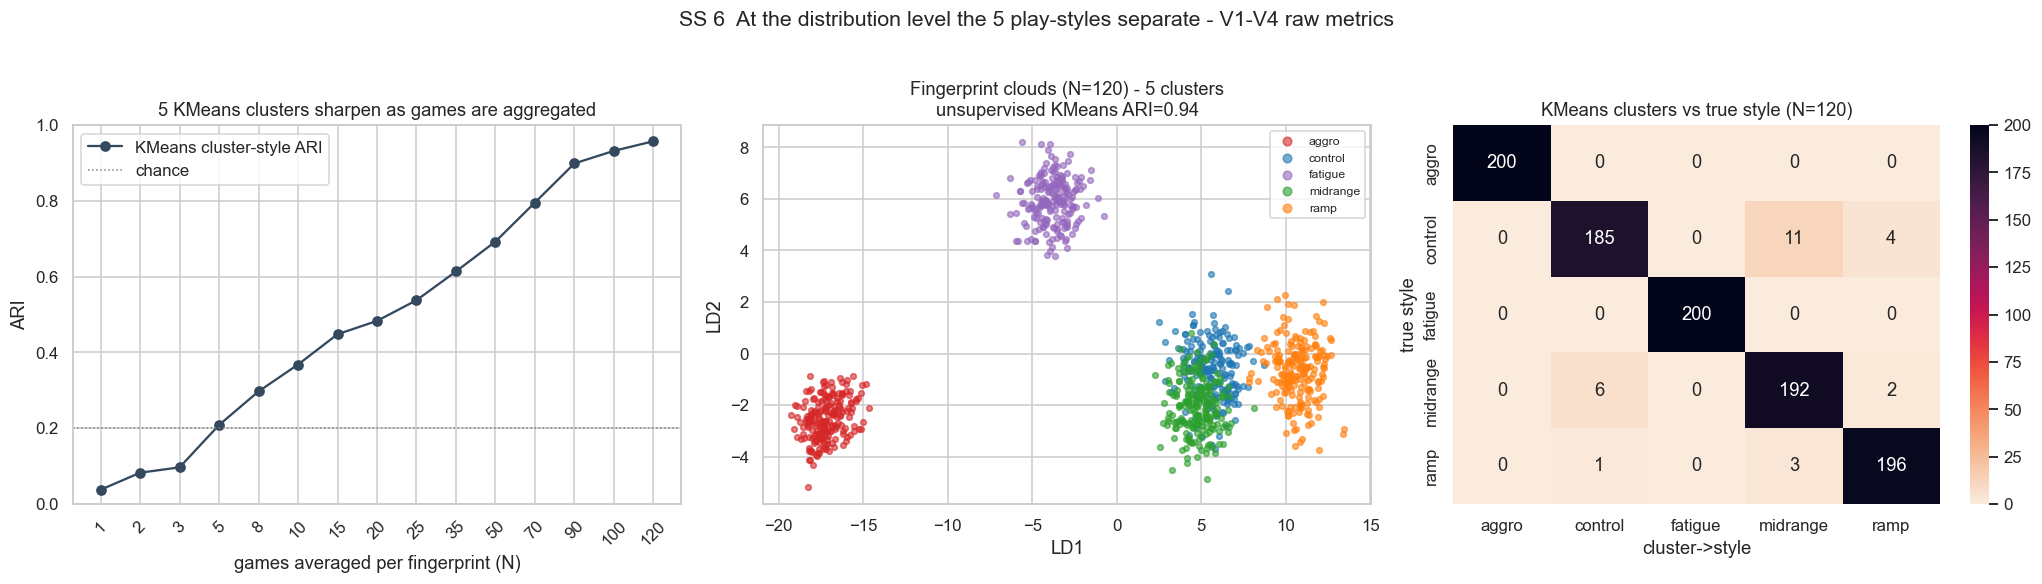

unsupervised KMeans(k=5) on N=120 fingerprints:  ARI=0.935


In [13]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

def bootstrap_fingerprints(N, reps=150, seed=0):
    rng = np.random.default_rng(seed); rows, lab = [], []
    for st in STYLE_ORDER:
        a = X[y == st]
        for _ in range(reps):
            rows.append(a[rng.integers(0, len(a), N)].mean(axis=0)); lab.append(st)
    return np.array(rows), np.array(lab)

Ns = [1, 2, 3, 5, 8, 10, 15, 20, 25, 35, 50, 70, 90, 100, 120]
aris = []
for N in Ns:
    Xb, yb = bootstrap_fingerprints(N)
    lab = KMeans(5, n_init=10, random_state=0).fit_predict(Xb)
    aris.append(adjusted_rand_score(yb, lab))

Xb, yb = bootstrap_fingerprints(120, reps=200)
labb = KMeans(5, n_init=10, random_state=0).fit_predict(Xb)
ari_b = adjusted_rand_score(yb, labb)
Lb = LinearDiscriminantAnalysis(n_components=2).fit(Xb, yb).transform(Xb)

fig, ax = plt.subplots(1, 3, figsize=(19, 5.4))
_xs = range(len(Ns))
ax[0].plot(_xs, aris, "o-", color="#34495e", label="KMeans cluster-style ARI")
ax[0].axhline(0.2, color="gray", ls=":", lw=1, label="chance")
ax[0].set_xticks(list(_xs)); ax[0].set_xticklabels(Ns, rotation=45)
ax[0].set_xlabel("games averaged per fingerprint (N)"); ax[0].set_ylabel("ARI")
ax[0].set_title("5 KMeans clusters sharpen as games are aggregated"); ax[0].legend(); ax[0].set_ylim(0, 1)
for st in STYLE_ORDER:
    m = (yb == st); ax[1].scatter(Lb[m, 0], Lb[m, 1], s=14, alpha=.6, color=STYLE_COLORS[st], label=st)
ax[1].set_title(f"Fingerprint clouds (N=120) - 5 clusters\nunsupervised KMeans ARI={ari_b:.2f}")
ax[1].legend(fontsize=8, markerscale=1.5); ax[1].set_xlabel("LD1"); ax[1].set_ylabel("LD2")
cmb, _ = cluster_confusion(yb, labb)
sns.heatmap(cmb, annot=True, fmt="d", cmap="rocket_r", ax=ax[2])
ax[2].set_title("KMeans clusters vs true style (N=120)")
fig.suptitle(f"SS 6  At the distribution level the 5 play-styles separate - {BLOCK_LABEL}", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()
print(f"unsupervised KMeans(k=5) on N=120 fingerprints:  ARI={ari_b:.3f}")

## 7 - Conclusion (raw / V1-V4 block)

* **Per game the 5 styles overlap** (SS 5): the same absolute metrics, pooled over 9 decks and random opponents, give a near-floor KMeans ARI. The signal is nonetheless real -- the supervised LDA sits clearly above the 0.20 chance line (SS 5b), and it **sharpens to near-perfect clusters once games are aggregated into fingerprints** (SS 6, SS 8).
* **The catch is deck leakage** (SS 9-10): the raw block scores high *within* a deck but its ARI **collapses toward chance across decks** (LODO/LOAO), because a metric like `raw_face_dmg_per_turn` mostly reports how aggressive the *deck* is. Per-deck z-scoring (SS 10 #3) recovers some of it -- that is exactly the *old* deck-normalization baseline.
* This notebook is the **reference floor** the choice-relative and combined notebooks are measured against.

## 8 - How many games to classify a player?

A **held-out** version of SS 6: split each style's games 50/50, fit an **LDA** on the train half only, then classify fingerprints of **N held-out games** and score with **ARI**. Q1: how many games are needed (chance line 0.20)? Q2: what does a single unknown game tell us (the N=1 confusion)? Per-style curves are **recall**, since ARI is a whole-partition score.

Smallest N (games averaged) for the held-out LDA to reach ARI:
  ARI >= 0.80: N = 20
  ARI >= 0.90: N = 50
  per-style recall >= 0.90:  aggro: 5 | control: 35 | fatigue: 8 | midrange: 25 | ramp: 25

Single-game ARI: 0.157  (chance 0.20)


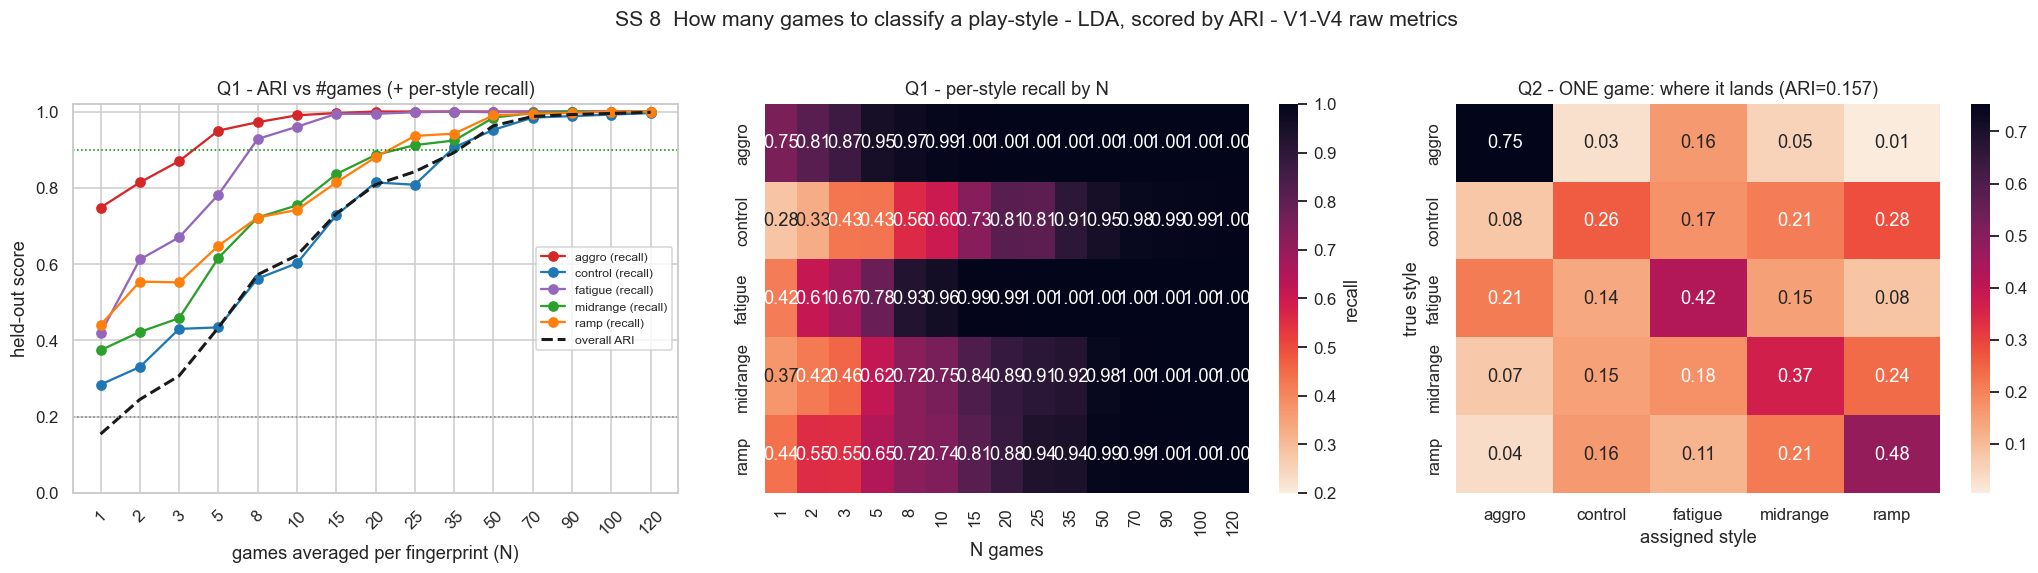

,ARI (LDA),aggro,control,fatigue,midrange,ramp
N,,,,,,
1,0.154,0.748,0.284,0.418,0.374,0.440
2,0.245,0.814,0.330,0.612,0.422,0.554
3,0.307,0.870,0.430,0.670,0.458,0.552
5,0.433,0.950,0.434,0.782,0.616,0.648
8,0.572,0.972,0.562,0.928,0.722,0.722
10,0.623,0.990,0.602,0.960,0.754,0.742
15,0.732,0.996,0.728,0.994,0.836,0.814
20,0.808,1.000,0.814,0.994,0.886,0.880
25,0.842,1.000,0.808,0.998,0.912,0.936


In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import confusion_matrix, adjusted_rand_score

# --- held-out 50/50 split within each style (disjoint games, decks pooled) ---
rng = np.random.default_rng(1)
G = df.copy(); G[FEATURES] = G[FEATURES].fillna(G[FEATURES].median())
tr_idx, te_idx = [], []
for st in STYLE_ORDER:
    idx = G.index[G["style"] == st].to_numpy().copy(); rng.shuffle(idx)
    h = len(idx) // 2; tr_idx += list(idx[:h]); te_idx += list(idx[h:])
tr, te = G.loc[tr_idx], G.loc[te_idx]
sc8 = StandardScaler().fit(tr[FEATURES].values)
Xtr, Xte = sc8.transform(tr[FEATURES].values), sc8.transform(te[FEATURES].values)
ytr, yte = styles_of(tr), styles_of(te)
trby = {s: Xtr[ytr == s] for s in STYLE_ORDER}
teby = {s: Xte[yte == s] for s in STYLE_ORDER}

def make_fps(by, N, reps, seed):
    r = np.random.default_rng(seed); Xs, ys = [], []
    for si, s in enumerate(STYLE_ORDER):
        a = by[s]
        for _ in range(reps):
            Xs.append(a[r.integers(0, len(a), N)].mean(0)); ys.append(si)
    return np.array(Xs), np.array(ys)

Ns = [1, 2, 3, 5, 8, 10, 15, 20, 25, 35, 50, 70, 90, 100, 120]
rows = []
for N in Ns:
    Xa, ya = make_fps(trby, N, 500, 10)
    lda = LinearDiscriminantAnalysis().fit(Xa, ya)          # supervised model = LDA
    Xc, yc = make_fps(teby, N, 500, 20)
    p = lda.predict(Xc)
    row = {"N": N, "ARI (LDA)": adjusted_rand_score(yc, p)}
    for si, s in enumerate(STYLE_ORDER):                    # ARI has no per-class form -> recall
        row[s] = (p[yc == si] == si).mean()
    rows.append(row)
acc = pd.DataFrame(rows).set_index("N")

def first_N(col, thr):
    hit = acc.index[acc[col] >= thr]
    return int(hit[0]) if len(hit) else f">{Ns[-1]}"
print("Smallest N (games averaged) for the held-out LDA to reach ARI:")
for thr in (0.80, 0.90):
    print(f"  ARI >= {thr:.2f}: N = {first_N('ARI (LDA)', thr)}")
print("  per-style recall >= 0.90:  " + " | ".join(f"{s}: {first_N(s, 0.90)}" for s in STYLE_ORDER))

lda1 = LinearDiscriminantAnalysis().fit(Xtr, ytr)
p1   = lda1.predict(Xte)
ari1 = adjusted_rand_score(yte, p1)
cm1  = confusion_matrix(yte, p1, labels=STYLE_ORDER, normalize="true")
print(f"\nSingle-game ARI: {ari1:.3f}  (chance 0.20)")

fig, ax = plt.subplots(1, 3, figsize=(19, 5.3))
_xs = range(len(acc.index))
for s in STYLE_ORDER:
    ax[0].plot(_xs, acc[s], "o-", color=STYLE_COLORS[s], label=f"{s} (recall)")
ax[0].plot(_xs, acc["ARI (LDA)"], "k--", lw=2, label="overall ARI")
ax[0].axhline(0.2, color="gray", ls=":", lw=1); ax[0].axhline(0.9, color="green", ls=":", lw=1)
ax[0].set_xticks(list(_xs)); ax[0].set_xticklabels(acc.index, rotation=45); ax[0].set_ylim(0, 1.02)
ax[0].set_xlabel("games averaged per fingerprint (N)"); ax[0].set_ylabel("held-out score")
ax[0].set_title("Q1 - ARI vs #games (+ per-style recall)"); ax[0].legend(fontsize=8)
hm = acc[STYLE_ORDER].T
sns.heatmap(hm, annot=True, fmt=".2f", cmap="rocket_r", vmin=0.2, vmax=1.0, ax=ax[1], cbar_kws={"label": "recall"})
ax[1].set_title("Q1 - per-style recall by N"); ax[1].set_xlabel("N games"); ax[1].set_ylabel("")
sns.heatmap(pd.DataFrame(cm1, index=STYLE_ORDER, columns=STYLE_ORDER), annot=True, fmt=".2f", cmap="rocket_r", ax=ax[2])
ax[2].set_title(f"Q2 - ONE game: where it lands (ARI={ari1:.3f})")
ax[2].set_ylabel("true style"); ax[2].set_xlabel("assigned style")
fig.suptitle(f"SS 8  How many games to classify a play-style - LDA, scored by ARI - {BLOCK_LABEL}", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()
display(acc.style.format("{:.3f}").background_gradient(cmap="rocket_r", subset=STYLE_ORDER + ["ARI (LDA)"])
        .set_caption("Held-out ARI (and per-style recall) of an N-game fingerprint"))

## 9 - Cross-deck transfer - the deck-agnostic test

Sections 1-8 pooled all decks. Here we ask whether the model reads the **player** or the **deck**: train on some decks and predict style on decks **never seen in training**. All three protocols use the **LDA**, are scored by **ARI**, and are swept over **N**, the number of games pooled into one fingerprint - so the deck-transfer question is asked the same way SS 8 asked the how-many-games question, not just at the single-game level.

* **within-deck** - train and test inside the *same* deck (50/50 held-out split per style), averaged over the 9 decks: the ceiling, where no deck boundary is ever crossed.
* **LODO** (leave-one-deck-out) - train on 8 decks, test on the 9th; mean over all 9.
* **LOAO** (leave-one-archetype-out) - hold out a whole deck **family** (aggro / midrange / highlander_control / combo_tempo), so no sibling deck leaks into training - the strict test.

The **gap between the within-deck curve and the two transfer curves is the deck leakage**, and how fast the transfer curves climb says how many unseen-deck games a fingerprint needs. This is where the three blocks should part ways: the raw block is expected to fall toward chance across decks at low N, the choice block to hold up better.

[V1-V4 raw metrics]  LDA on N-game fingerprints, scored by ARI   chance = 0.20


,within-deck (9),cross-deck LODO (9),cross-family LOAO (4)
N games pooled,,,
1,0.219,0.133,0.098
2,0.331,0.203,0.181
3,0.413,0.245,0.211
5,0.525,0.302,0.269
8,0.618,0.341,0.296
10,0.679,0.353,0.297
15,0.760,0.397,0.353
20,0.828,0.376,0.386
25,0.857,0.399,0.398


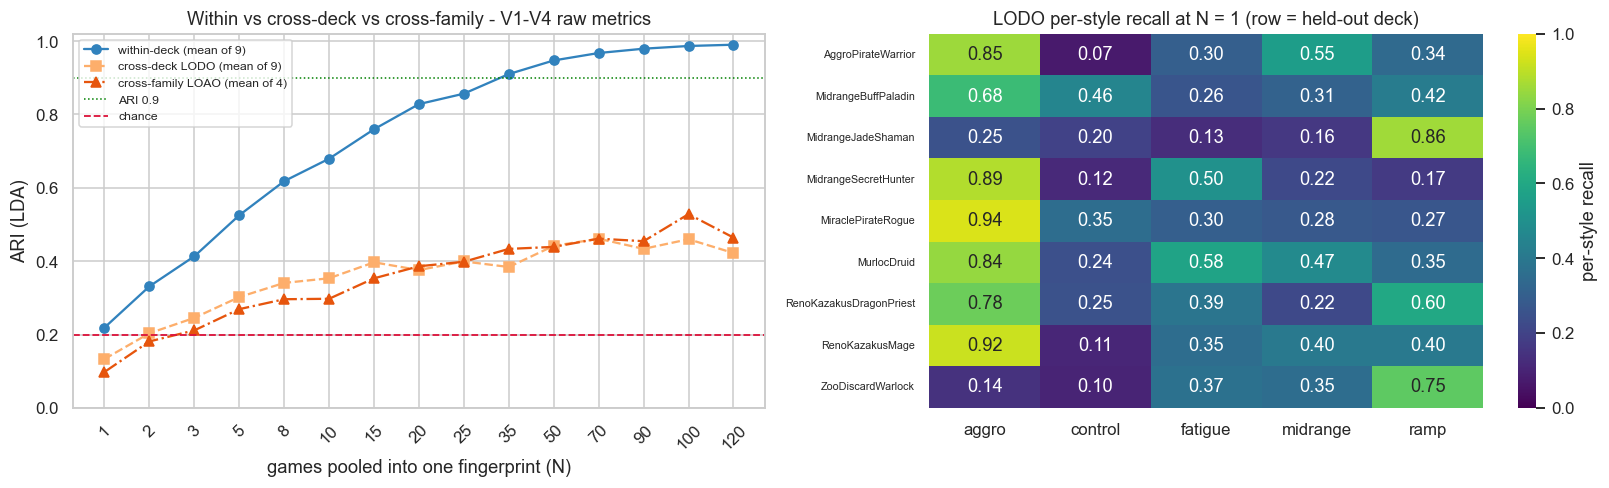

In [15]:
# ===== SS 9a - within-deck vs cross-deck vs cross-family transfer, as games are pooled =====
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import adjusted_rand_score, confusion_matrix

NS_CROSS = (1, 2, 3, 5, 8, 10, 15, 20, 25, 35, 50, 70, 90, 100, 120)

def _xy(frame, feats, fill_from=None):
    med = (frame if fill_from is None else fill_from)[feats].median()
    return frame[feats].fillna(med).fillna(0.0).values, styles_of(frame)

def _fp_sample(by, N, reps, seed):
    """`reps` fingerprints per style, each the mean of N games drawn with replacement."""
    r = np.random.default_rng(seed); Xs, ys = [], []
    for si, s in enumerate(STYLE_ORDER):
        if len(by[s]) == 0:
            continue
        for _ in range(reps):
            Xs.append(by[s][r.integers(0, len(by[s]), N)].mean(0)); ys.append(si)
    return np.array(Xs), np.array(ys)

def _fold_curve(tr, te, feats, Ns, reps):
    """One train/test split -> ARI at every N. Scaler and NaN medians come from the TRAIN side only."""
    Xtr, ytr = _xy(tr, feats); Xte, yte = _xy(te, feats, fill_from=tr)
    sc = StandardScaler().fit(Xtr); Xtr, Xte = sc.transform(Xtr), sc.transform(Xte)
    trby = {s: Xtr[ytr == s] for s in STYLE_ORDER}; teby = {s: Xte[yte == s] for s in STYLE_ORDER}
    out = {}
    for N in Ns:
        Xa, ya = _fp_sample(trby, N, reps, 10); Xb, yb = _fp_sample(teby, N, reps, 20)
        out[N] = adjusted_rand_score(yb, LinearDiscriminantAnalysis().fit(Xa, ya).predict(Xb))
    return out

def cross_agg_curve(frame, feats, split_col, Ns=NS_CROSS, reps=300):
    """Hold out each group of `split_col`, train on the rest. Mean ARI over held-out groups, per N."""
    out = {N: [] for N in Ns}
    for held in sorted(frame[split_col].unique()):
        for N, v in _fold_curve(frame[frame[split_col] != held],
                                frame[frame[split_col] == held], feats, Ns, reps).items():
            out[N].append(v)
    return pd.Series({N: float(np.mean(v)) for N, v in out.items()})

def within_agg_curve(frame, feats, Ns=NS_CROSS, reps=300, seed=1):
    """Same protocol, but train and test stay INSIDE one deck (50/50 held-out split per style), so no
    deck boundary is ever crossed. This is the ceiling the two transfer curves are measured against."""
    rng = np.random.default_rng(seed)
    out = {N: [] for N in Ns}
    for deck, g in frame.groupby("deck"):
        tr_idx, te_idx = [], []
        for st in STYLE_ORDER:
            idx = g.index[g["style"] == st].to_numpy().copy(); rng.shuffle(idx)
            h = len(idx) // 2; tr_idx += list(idx[:h]); te_idx += list(idx[h:])
        for N, v in _fold_curve(frame.loc[tr_idx], frame.loc[te_idx], feats, Ns, reps).items():
            out[N].append(v)
    return pd.Series({N: float(np.mean(v)) for N, v in out.items()})

def lodo_per_style_recall(feats):
    """Single-game LODO recall per style, one row per held-out deck (the N=1 slice of the LODO curve)."""
    per_style = {}
    for held in sorted(df["deck"].unique()):
        tr = df[df["deck"] != held]; te = df[df["deck"] == held]
        Xtr, ytr = _xy(tr, feats); Xte, yte = _xy(te, feats, fill_from=tr)
        sc = StandardScaler().fit(Xtr)
        pred = LinearDiscriminantAnalysis().fit(sc.transform(Xtr), ytr).predict(sc.transform(Xte))
        cm = confusion_matrix(yte, pred, labels=STYLE_ORDER, normalize="true")
        per_style[held] = dict(zip(STYLE_ORDER, np.diag(cm)))
    return per_style

curve_within = within_agg_curve(df, FEATURES)                # 9 decks, 50/50 inside each
curve_lodo   = cross_agg_curve(df, FEATURES, "deck")         # leave-one-DECK-out (9 folds)
curve_loao   = cross_agg_curve(df, FEATURES, "deck_family")  # leave-one-ARCHETYPE-out (4 folds)
lodo_ps      = lodo_per_style_recall(FEATURES)

curves = pd.DataFrame({"within-deck (9)":       curve_within,
                       "cross-deck LODO (9)":   curve_lodo,
                       "cross-family LOAO (4)": curve_loao})
curves.index.name = "N games pooled"
print(f"[{BLOCK_LABEL}]  LDA on N-game fingerprints, scored by ARI   chance = 0.20")
display(curves.round(3))

fig, ax = plt.subplots(1, 2, figsize=(15, 4.6))
xs = range(len(NS_CROSS))
ax[0].plot(xs, curve_within.values, "o-",  color="#3182bd", label="within-deck (mean of 9)")
ax[0].plot(xs, curve_lodo.values,   "s--", color="#fdae6b", label="cross-deck LODO (mean of 9)")
ax[0].plot(xs, curve_loao.values,   "^-.", color="#e6550d", label="cross-family LOAO (mean of 4)")
ax[0].axhline(0.9, color="green", ls=":", lw=1, label="ARI 0.9")
ax[0].axhline(0.20, color="crimson", ls="--", lw=1.2, label="chance")
ax[0].set_xticks(list(xs)); ax[0].set_xticklabels(NS_CROSS, rotation=45); ax[0].set_ylim(0, 1.02)
ax[0].set_xlabel("games pooled into one fingerprint (N)"); ax[0].set_ylabel("ARI (LDA)")
ax[0].set_title(f"Within vs cross-deck vs cross-family - {BLOCK_LABEL}"); ax[0].legend(fontsize=8)
psM = pd.DataFrame(lodo_ps).T[STYLE_ORDER]
sns.heatmap(psM.reindex(sorted(psM.index)), annot=True, fmt=".2f", cmap="viridis", vmin=0, vmax=1,
            ax=ax[1], cbar_kws={"label": "per-style recall"})
ax[1].set_title("LODO per-style recall at N = 1 (row = held-out deck)")
ax[1].set_yticklabels(ax[1].get_yticklabels(), rotation=0, fontsize=7)
fig.tight_layout(); plt.show()

       within-deck:  N for ARI 0.5 = 5   N for ARI 0.9 = 35   best 0.990 at N = 120
   cross-deck LODO:  N for ARI 0.5 = None   N for ARI 0.9 = None   best 0.461 at N = 70
 cross-family LOAO:  N for ARI 0.5 = 100   N for ARI 0.9 = None   best 0.528 at N = 100


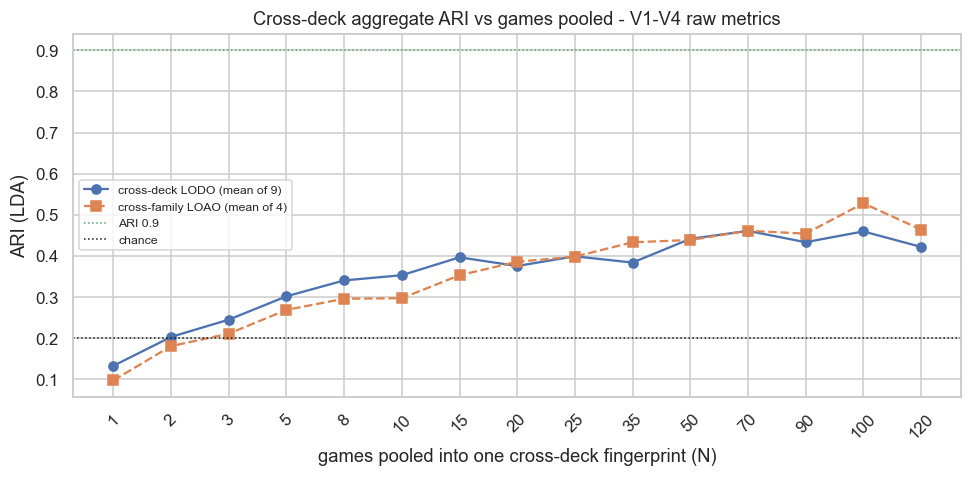

In [16]:
# ===== SS 9b - the two transfer curves on their own, without the within-deck ceiling =====
# Both curves were computed in SS 9a (`cross_agg_curve`); nothing is recomputed here.
for name, c in [("within-deck", curve_within), ("cross-deck LODO", curve_lodo), ("cross-family LOAO", curve_loao)]:
    n50 = next((N for N in c.index if c[N] >= 0.5), None)
    n90 = next((N for N in c.index if c[N] >= 0.9), None)
    print(f"{name:>18}:  N for ARI 0.5 = {n50}   N for ARI 0.9 = {n90}   "
          f"best {c.max():.3f} at N = {c.idxmax()}")

fig, ax = plt.subplots(figsize=(9, 4.5))
xs = range(len(curve_lodo.index))
ax.plot(xs, curve_lodo.values, "o-", label="cross-deck LODO (mean of 9)")
ax.plot(xs, curve_loao.values, "s--", label="cross-family LOAO (mean of 4)")
ax.axhline(0.9, color="g", ls=":", lw=1, label="ARI 0.9"); ax.axhline(0.2, color="k", ls=":", lw=1, label="chance")
ax.set_xticks(list(xs)); ax.set_xticklabels(curve_lodo.index, rotation=45)
ax.set_xlabel("games pooled into one cross-deck fingerprint (N)"); ax.set_ylabel("ARI (LDA)")
ax.set_title(f"Cross-deck aggregate ARI vs games pooled - {BLOCK_LABEL}")
ax.legend(fontsize=8); fig.tight_layout(); plt.show()

## 10 - Reviewer follow-ups - Prof. Kokolo's feedback

The three graphs Prof. Kokolo asked for, computed **on this block's own features**:

* **#1 - Confusion at N = 1, 10, 25, 50 pooled games** - *where* the mistakes go as games are aggregated (held-out LDA, each panel labelled with its ARI).
* **#2 - ARI as N grows** - both the unsupervised (KMeans) and the supervised (LDA) curve between the N=1 and N=120 extremes.
* **#3 - Cross-deck domain-shift correction** - re-express each feature as a deviation from the *same-deck average player* (per-deck z-score) and re-test cross-family transfer.

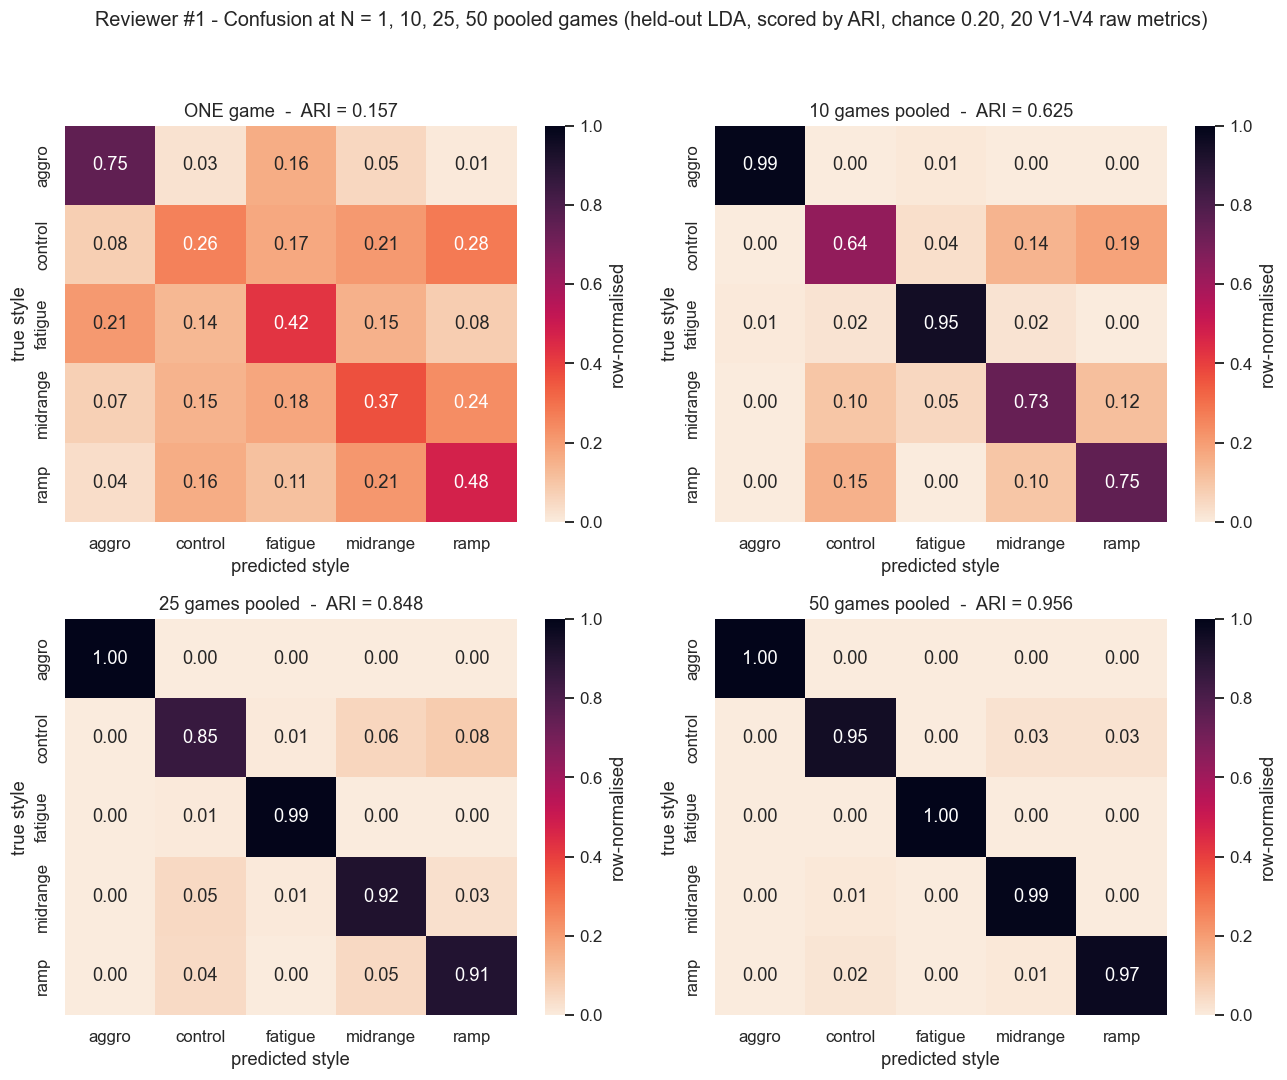

In [17]:
# ===== Reviewer #1 - confusion matrices at N = 1, 10, 25, 50 pooled games =====
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import confusion_matrix, adjusted_rand_score

def _heldout_split(frame, feats, seed=1):
    rng = np.random.default_rng(seed)
    G = frame.copy(); G[feats] = G[feats].fillna(G[feats].median())
    tr_idx, te_idx = [], []
    for st in STYLE_ORDER:
        idx = G.index[G["style"] == st].to_numpy().copy(); rng.shuffle(idx)
        h = len(idx) // 2; tr_idx += list(idx[:h]); te_idx += list(idx[h:])
    sc = StandardScaler().fit(G.loc[tr_idx, feats].values)
    Xtr = sc.transform(G.loc[tr_idx, feats].values); Xte = sc.transform(G.loc[te_idx, feats].values)
    ytr = styles_of(G.loc[tr_idx]); yte = styles_of(G.loc[te_idx])
    return Xtr, ytr, Xte, yte

def _fps(Xby, N, reps, seed):
    r = np.random.default_rng(seed); Xs, ys = [], []
    for si, s in enumerate(STYLE_ORDER):
        a = Xby[s]
        for _ in range(reps):
            Xs.append(a[r.integers(0, len(a), N)].mean(0)); ys.append(si)
    return np.array(Xs), np.array(ys)

def confusion_at_N(frame, feats, N, reps=600, seed=1):
    Xtr, ytr, Xte, yte = _heldout_split(frame, feats, seed)
    trby = {s: Xtr[ytr == s] for s in STYLE_ORDER}; teby = {s: Xte[yte == s] for s in STYLE_ORDER}
    if N == 1:
        pred = LinearDiscriminantAnalysis().fit(Xtr, ytr).predict(Xte)
        cm = confusion_matrix(yte, pred, labels=STYLE_ORDER, normalize="true")
        ari = adjusted_rand_score(yte, pred)
    else:
        Xa, ya = _fps(trby, N, reps, seed + 10); Xb, yb = _fps(teby, N, reps, seed + 20)
        pb = LinearDiscriminantAnalysis().fit(Xa, ya).predict(Xb)
        cm = confusion_matrix(yb, pb, labels=range(len(STYLE_ORDER)), normalize="true")
        ari = adjusted_rand_score(yb, pb)
    return cm, ari

fig, ax = plt.subplots(2, 2, figsize=(12, 10))
for a, N in zip(ax.ravel(), [1, 10, 25, 50]):
    cm, ari = confusion_at_N(df, FEATURES, N)
    sns.heatmap(pd.DataFrame(cm, index=STYLE_ORDER, columns=STYLE_ORDER), annot=True, fmt=".2f",
                cmap="rocket_r", vmin=0, vmax=1, ax=a, cbar_kws={"label": "row-normalised"})
    a.set_title(f"{'ONE game' if N == 1 else f'{N} games pooled'}  -  ARI = {ari:.3f}")
    a.set_ylabel("true style"); a.set_xlabel("predicted style")
fig.suptitle(f"Reviewer #1 - Confusion at N = 1, 10, 25, 50 pooled games "
             f"(held-out LDA, scored by ARI, chance 0.20, {len(FEATURES)} {BLOCK_LABEL})", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()

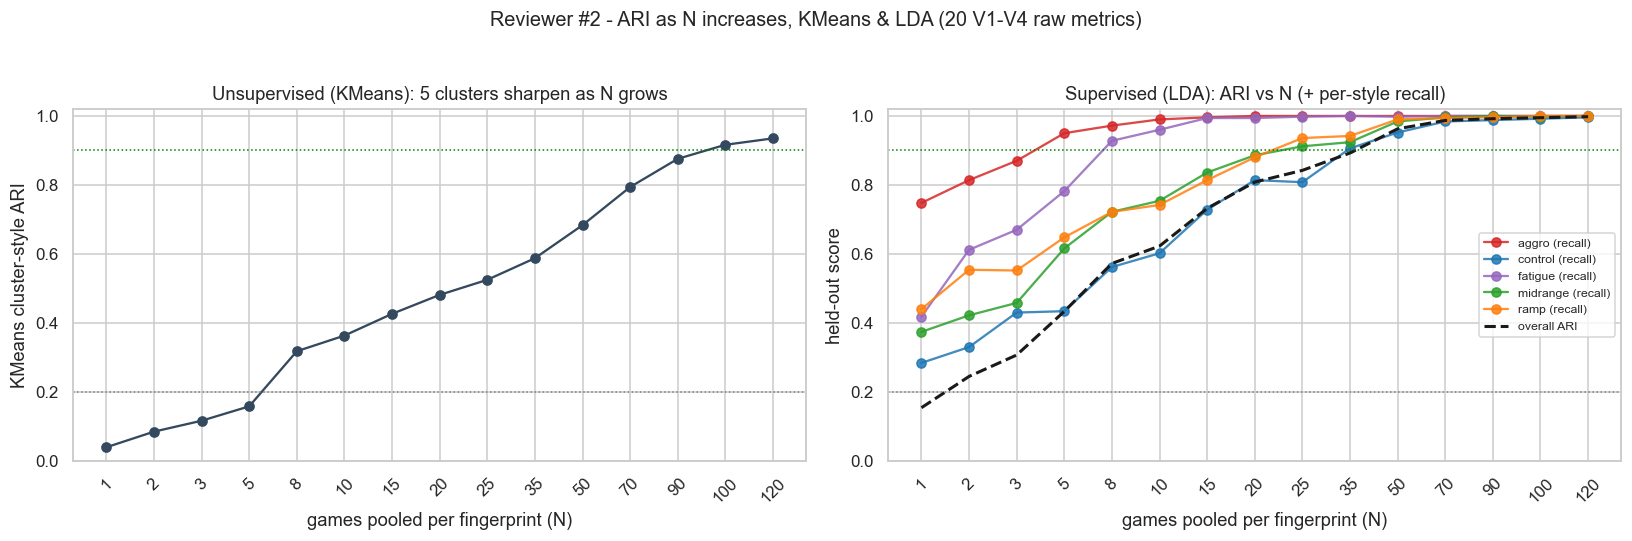

In [18]:
# ===== Reviewer #2 - ARI as N increases, unsupervised (KMeans) and supervised (LDA) =====
from sklearn.cluster import KMeans
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import adjusted_rand_score

Ns = [1, 2, 3, 5, 8, 10, 15, 20, 25, 35, 50, 70, 90, 100, 120]

def _boot(N, reps=200, seed=0):
    rng = np.random.default_rng(seed); rows, lab = [], []
    for st in STYLE_ORDER:
        a = X[y == st]
        for _ in range(reps):
            rows.append(a[rng.integers(0, len(a), N)].mean(0)); lab.append(st)
    return np.array(rows), np.array(lab)

ari = []
for N in Ns:
    Xb, yb = _boot(N)
    ari.append(adjusted_rand_score(yb, KMeans(5, n_init=10, random_state=0).fit_predict(Xb)))

Xtr, ytr, Xte, yte = _heldout_split(df, FEATURES)
trby = {s: Xtr[ytr == s] for s in STYLE_ORDER}; teby = {s: Xte[yte == s] for s in STYLE_ORDER}
ari_overall, rec_per = [], {s: [] for s in STYLE_ORDER}
for N in Ns:
    Xa, ya = _fps(trby, N, 500, 10); Xc, yc = _fps(teby, N, 500, 20)
    p = LinearDiscriminantAnalysis().fit(Xa, ya).predict(Xc)
    ari_overall.append(adjusted_rand_score(yc, p))
    for si, s in enumerate(STYLE_ORDER):      # ARI has no per-class form -> recall
        rec_per[s].append((p[yc == si] == si).mean())

fig, ax = plt.subplots(1, 2, figsize=(15, 5)); xs = range(len(Ns))
ax[0].plot(xs, ari, "o-", color="#34495e"); ax[0].axhline(0.9, color="green", ls=":", lw=1)
ax[0].axhline(0.2, color="gray", ls=":", lw=1)
ax[0].set_xticks(list(xs)); ax[0].set_xticklabels(Ns, rotation=45); ax[0].set_ylim(0, 1.02)
ax[0].set_xlabel("games pooled per fingerprint (N)"); ax[0].set_ylabel("KMeans cluster-style ARI")
ax[0].set_title("Unsupervised (KMeans): 5 clusters sharpen as N grows")
for s in STYLE_ORDER:
    ax[1].plot(xs, rec_per[s], "o-", color=STYLE_COLORS[s], label=f"{s} (recall)", alpha=.85)
ax[1].plot(xs, ari_overall, "k--", lw=2, label="overall ARI")
ax[1].axhline(0.9, color="green", ls=":", lw=1); ax[1].axhline(0.2, color="gray", ls=":", lw=1)
ax[1].set_xticks(list(xs)); ax[1].set_xticklabels(Ns, rotation=45); ax[1].set_ylim(0, 1.02)
ax[1].set_xlabel("games pooled per fingerprint (N)"); ax[1].set_ylabel("held-out score")
ax[1].set_title("Supervised (LDA): ARI vs N (+ per-style recall)"); ax[1].legend(fontsize=8)
fig.suptitle(f"Reviewer #2 - ARI as N increases, KMeans & LDA ({len(FEATURES)} {BLOCK_LABEL})", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()

### Reviewer #3 - cross-deck aggregation + domain-shift correction

How far a game deviates from the **average player of its own deck** removes the deck's overall bias before we test transfer. The raw block should gain the most from this correction (it is the most deck-biased); the choice block the least (it is already deck-normalized by construction).

Single-game cross-deck / cross-family ARI (LDA, chance = 0.20):


,raw features,deck-normalised
LDA LODO (9 decks),0.148,0.173
LDA LOAO (4 families),0.113,0.164


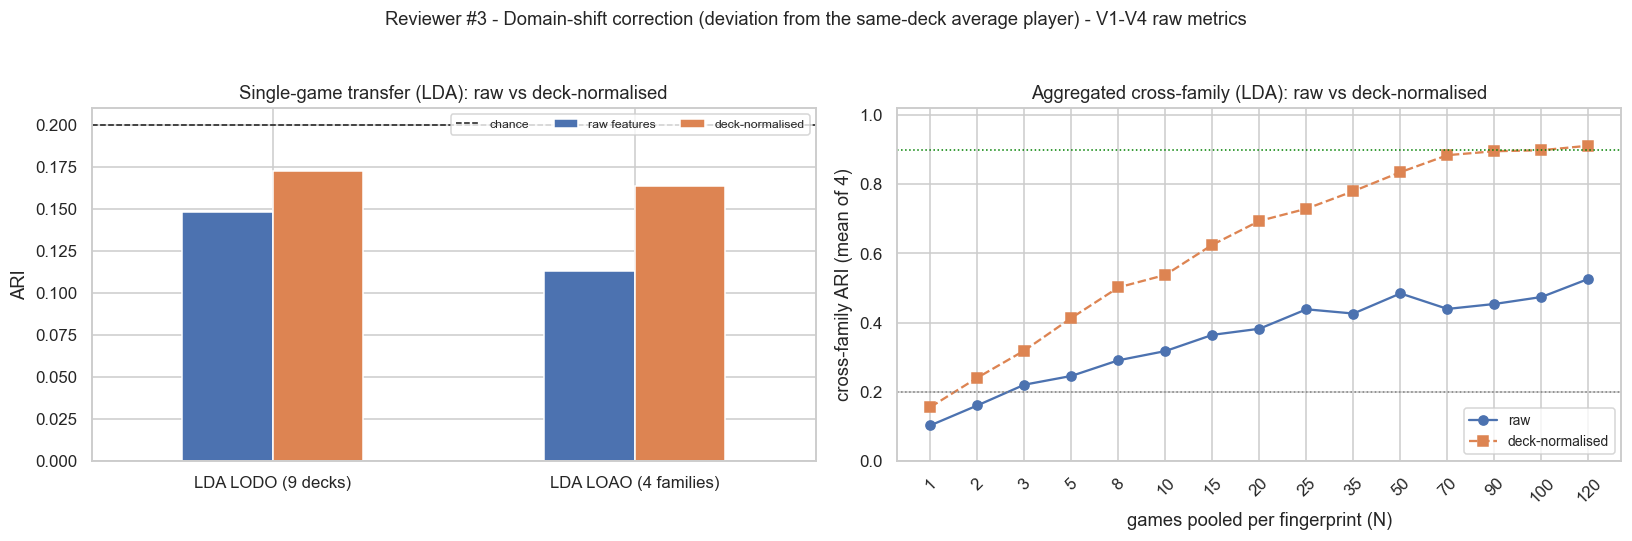

Read: per-deck z-scoring removes the deck's overall bias; compare how much it moves THIS block vs the others -- the raw block should gain the most, the choice block the least.


In [19]:
# ===== Reviewer #3 - cross-deck domain-shift correction (per-deck z-score) =====
# Re-express each feature as a deviation from the AVERAGE PLAYER OF THE SAME DECK, then re-test
# transfer. This is the "old" deck-normalization; the comparison shows how much each block relies on it.
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import adjusted_rand_score

def deck_zscore(frame, feats):
    g = frame.copy()
    g[feats] = g[feats].fillna(g.groupby("deck")[feats].transform("median")).fillna(0.0)
    g[feats] = g.groupby("deck")[feats].transform(lambda s: (s - s.mean()) / (s.std(ddof=0) + 1e-9))
    return g

def holdout_single(frame, feats, split_col):
    """Single-game LDA transfer: train on all groups but one, test on the held-out group. Mean ARI."""
    aris = []
    for held in sorted(frame[split_col].unique()):
        tr = frame[frame[split_col] != held]; te = frame[frame[split_col] == held]
        med = tr[feats].median()
        Xtr = tr[feats].fillna(med).fillna(0.0).values; Xte = te[feats].fillna(med).fillna(0.0).values
        ytr = styles_of(tr); yte = styles_of(te)
        sc = StandardScaler().fit(Xtr); Xtr, Xte = sc.transform(Xtr), sc.transform(Xte)
        clf = LinearDiscriminantAnalysis()
        aris.append(adjusted_rand_score(yte, clf.fit(Xtr, ytr).predict(Xte)))
    return float(np.mean(aris))

df_dz = deck_zscore(df, FEATURES)                       # domain-corrected features
bars = {}
for label, frame in [("raw features", df), ("deck-normalised", df_dz)]:
    bars[label] = {"LDA LODO (9 decks)":    holdout_single(frame, FEATURES, "deck"),
                   "LDA LOAO (4 families)": holdout_single(frame, FEATURES, "deck_family")}
barsdf = pd.DataFrame(bars)
print("Single-game cross-deck / cross-family ARI (LDA, chance = 0.20):"); display(barsdf.round(3))

curve_raw = cross_agg_curve(df,    FEATURES, "deck_family", reps=250)
curve_dz  = cross_agg_curve(df_dz, FEATURES, "deck_family", reps=250)

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
barsdf.plot.bar(ax=ax[0]); ax[0].axhline(0.20, color="k", ls="--", lw=1, label="chance")
ax[0].set_title("Single-game transfer (LDA): raw vs deck-normalised"); ax[0].set_ylabel("ARI")
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=0); ax[0].legend(fontsize=8, ncol=3)
xs = range(len(curve_raw.index))
ax[1].plot(xs, curve_raw.values, "o-", label="raw")
ax[1].plot(xs, curve_dz.values, "s--", label="deck-normalised")
ax[1].axhline(0.9, color="green", ls=":", lw=1); ax[1].axhline(0.2, color="gray", ls=":", lw=1)
ax[1].set_xticks(list(xs)); ax[1].set_xticklabels(curve_raw.index, rotation=45); ax[1].set_ylim(0, 1.02)
ax[1].set_xlabel("games pooled per fingerprint (N)"); ax[1].set_ylabel("cross-family ARI (mean of 4)")
ax[1].set_title("Aggregated cross-family (LDA): raw vs deck-normalised"); ax[1].legend(fontsize=9)
fig.suptitle(f"Reviewer #3 - Domain-shift correction (deviation from the same-deck average player) - {BLOCK_LABEL}",
             fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()
print("Read: per-deck z-scoring removes the deck's overall bias; compare how much it moves THIS block "
      "vs the others -- the raw block should gain the most, the choice block the least.")